# Koushik — CNN+BiLSTM + AgroNT Hybrid (v2)


## Cell 1 — Install + verify GPU

In [ ]:
import subprocess, sys, os, time, warnings
warnings.filterwarnings('ignore')
print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout[:300])
subprocess.run([sys.executable,'-m','pip','install','-q',
    'transformers==4.40.0','accelerate','sentencepiece','scipy'], check=True)
import torch, torch.nn as nn, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.patches import FancyBboxPatch, Patch
from scipy.stats import pearsonr
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from itertools import product
from IPython.display import display
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device  : {DEVICE}")
print("All packages ready ✓")

Thu Apr 23 08:24:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : NVIDIA L4
VRAM    : 23.7 GB
Device  : cuda
All packages ready ✓


## Cell 2 — Upload dataset

In [ ]:
from google.colab import files
print("Upload: Capstone project data resource-1.xlsx")
uploaded  = files.upload()
XLSX_PATH = next(iter(uploaded))
print(f"Uploaded: {XLSX_PATH}  ({os.path.getsize(XLSX_PATH)/1e6:.1f} MB) ✓")

Upload: Capstone project data resource-1.xlsx


Saving Capstone project data resource-1.xlsx to Capstone project data resource-1.xlsx
Uploaded: Capstone project data resource-1.xlsx  (20.2 MB) ✓


## Cell 3 — Load + merge Tables 1 & 2

In [ ]:
print("Reading Excel...")
df1 = pd.read_excel(XLSX_PATH, sheet_name="Supplementary Table 1", skiprows=3)
df2 = pd.read_excel(XLSX_PATH, sheet_name="Supplementary Table 2", skiprows=3)
df1.columns = df1.columns.str.strip().str.lower()
df2.columns = df2.columns.str.strip().str.lower()
if "promoter" in df2.columns and "promotor" not in df2.columns:
    df2 = df2.rename(columns={"promoter":"promotor"})
df5 = pd.merge(df1, df2, left_on="gene", right_on="promotor",
               how="inner", suffixes=("_t1","_t2"))
print(f"Table 1 : {len(df1):,} | Table 2 : {len(df2):,} | Merged : {len(df5):,}")

COND_COLS = [c for c in df5.columns
             if any(k in str(c) for k in ["no enhancer","with enhancer"])]
COND_LABELS = ["No enh, Dark, Tobacco","No enh, Dark, Maize",
               "With enh, Dark, Tobacco","With enh, Dark, Maize",
               "No enh, Light, Tobacco","With enh, Light, Tobacco"]
print(f"Condition columns: {len(COND_COLS)}")

cond_dfs = {}
print("\nPer-condition non-null counts:")
for col in COND_COLS:
    sub = df5[["gene","species_t1","sequence","gc",col]].dropna(subset=[col]).reset_index(drop=True)
    cond_dfs[col] = sub
    print(f"  {col[:40]:<40}: {len(sub):,}")
display(df5.head(3))
print("\nGC content range:", df5["gc"].min(), "—", df5["gc"].max())
print("Species present:", df5["species_t1"].unique().tolist())

Reading Excel...
Table 1 : 79,838 | Table 2 : 78,677 | Merged : 78,677
Condition columns: 6

Per-condition non-null counts:
  no enhancer, dark,
tobacco leaves       : 76,177
  no enhancer, dark,
maize protoplasts    : 76,851
  with enhancer, dark,
tobacco leaves     : 72,221
  with enhancer, dark,
maize protoplasts  : 75,862
  no enhancer, light,
tobacco leaves      : 75,375
  with enhancer, light,
tobacco leaves    : 71,859


,gene,species_t1,barcodes,type,chromosome,start,end,strand,gc,utr,mutations,sequence,promotor,species_t2,"no enhancer, dark,\ntobacco leaves","no enhancer, dark,\nmaize protoplasts","with enhancer, dark,\ntobacco leaves","with enhancer, dark,\nmaize protoplasts","no enhancer, light,\ntobacco leaves","with enhancer, light,\ntobacco leaves"
0,AT5G04255,Arabidopsis,36,miRNA,5,9362651,9362820,-,0.200000,True,NaN,GAATATAACGAAAGTAGTACTTAATTTGTTTACATAATTTTATTTT...,AT5G04255,Arabidopsis,-2.020278,-3.376616,0.691509,-1.957020,-2.242390,0.289571
1,AT1G31358,Arabidopsis,1,miRNA,1,11230608,11230777,-,0.223529,True,NaN,TTACGTTACTGTTAAAGACTAGTTCATGACTAGTTTAACTCAATTT...,AT1G31358,Arabidopsis,NaN,-2.016302,NaN,1.294134,-1.082743,NaN
2,AT4G07100,Arabidopsis,3,miRNA,4,11963074,11963243,-,0.223529,True,NaN,CATTAAGTAAACTCTGAAAGCAATATAAATAGATGAAAGCAAACGA...,AT4G07100,Arabidopsis,-1.505127,-5.041712,2.244046,-3.061829,-0.929134,2.771359



GC content range: 0.164705882352941 — 0.841176470588235
Species present: ['Arabidopsis', 'Sorghum', 'Maize']


## Cell 4 — Load AgroNT encoder

In [ ]:
from transformers import AutoTokenizer, AutoModel
MODEL_NAME   = "InstaDeepAI/agro-nucleotide-transformer-1b"
print(f"Loading {MODEL_NAME} ...")
tokenizer    = AutoTokenizer.from_pretrained(MODEL_NAME)
agro_encoder = AutoModel.from_pretrained(MODEL_NAME, torch_dtype=torch.float16)
agro_encoder = agro_encoder.to(DEVICE); agro_encoder.eval()
for param in agro_encoder.parameters(): param.requires_grad = False
AGRO_HIDDEN_DIM = agro_encoder.config.hidden_size
print(f"AgroNT loaded ✓  hidden={AGRO_HIDDEN_DIM}  VRAM={torch.cuda.memory_allocated()/1e9:.2f}GB")

Loading InstaDeepAI/agro-nucleotide-transformer-1b ...


tokenizer_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/101 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/3.97G [00:00<?, ?B/s]

Some weights of EsmModel were not initialized from the model checkpoint at InstaDeepAI/agro-nucleotide-transformer-1b and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


AgroNT loaded ✓  hidden=1500  VRAM=1.97GB


## Cell 5a — AgroNT tokenization

In [ ]:
SEQ_LEN=170; K=6; N_KMERS=SEQ_LEN-K+1  # 165
def get_kmers(seq, k=6):
    seq = seq.upper().strip()
    return [seq[i:i+k] for i in range(len(seq)-k+1)]
def tokenize_sequence(seq):
    return tokenizer(" ".join(get_kmers(seq)),
                     return_tensors="pt", truncation=False, padding=False)
test_seq=df5["sequence"].iloc[0]
tokens=tokenize_sequence(test_seq)
print(f"Input : {len(test_seq)} bp")
print(f"Tokens: {tokens['input_ids'].shape}  Hidden: {AGRO_HIDDEN_DIM}")
print("AgroNT tokenization verified ✓")

Input : 170 bp
Tokens: torch.Size([1, 166])  Hidden: 1500
AgroNT tokenization verified ✓


## Cell 5b — Feature encoding functions (GC + species)

> **New in v2:** `compute_gc` and `encode_species` — both used in dataset + model.

In [ ]:
SEQ_LEN = 170

# ── Branch A: one-hot ─────────────────────────────────────────────────────────
def one_hot_encode(seq):
    NT_MAP = {"A":0,"T":1,"C":2,"G":3}
    mat = np.zeros((4, SEQ_LEN), dtype=np.float32)
    for i, nt in enumerate(seq.upper()[:SEQ_LEN]):
        if nt in NT_MAP: mat[NT_MAP[nt], i] = 1.0
    return mat

# ── GC content scalar ─────────────────────────────────────────────────────────
GC_DIM = 1
def compute_gc(seq):
    s = seq.upper()
    return float(sum(c in "GC" for c in s) / len(s)) if s else 0.0

# ── Species one-hot ───────────────────────────────────────────────────────────
SPECIES_LIST = sorted(df5["species_t1"].dropna().unique().tolist())
SPECIES_DIM  = len(SPECIES_LIST)
SPECIES_IDX  = {sp: i for i, sp in enumerate(SPECIES_LIST)}

def encode_species(sp):
    vec = np.zeros(SPECIES_DIM, dtype=np.float32)
    sp  = str(sp).strip()
    if sp in SPECIES_IDX:
        vec[SPECIES_IDX[sp]] = 1.0
    return vec

# ── Sanity check ──────────────────────────────────────────────────────────────
test_seq = df5["sequence"].iloc[0]
print(f"Sequence length  : {len(test_seq)} bp")
print(f"One-hot shape    : {one_hot_encode(test_seq).shape}")
print(f"GC content       : {compute_gc(test_seq):.4f}")
print(f"Species list     : {SPECIES_LIST}  dim={SPECIES_DIM}")
print(f"Species encoding : {encode_species(df5['species_t1'].iloc[0])}")
print("Encoding functions verified ✓")

Sequence length  : 170 bp
One-hot shape    : (4, 170)
GC content       : 0.2000
Species list     : ['Arabidopsis', 'Maize', 'Sorghum']  dim=3
Species encoding : [1. 0. 0.]
Encoding functions verified ✓


## Cell 6 — Precompute + cache AgroNT embeddings

> ⏱ ~35-40 min on T4. Checkpoints every 5000 seqs. Re-run after disconnect — loads instantly.

In [ ]:
if "agro_encoder" not in dir(): raise RuntimeError("Run Cell 4 first.")
print(f"agro_encoder: {next(agro_encoder.parameters()).device} ✓  frozen:{not next(agro_encoder.parameters()).requires_grad} ✓  hidden:{AGRO_HIDDEN_DIM} ✓\n")

CACHE_FILE="agro_embeddings_cache.pt"; BATCH_SIZE=32; SAVE_EVERY=5000

if os.path.exists(CACHE_FILE):
    print(f"✓ Cache found — loading from disk...")
    cached=torch.load(CACHE_FILE)
    all_agro_embs=cached["embeddings"]; unique_seqs=cached["sequences"]
    seq_to_emb={seq.strip():all_agro_embs[i] for i,seq in enumerate(unique_seqs)}
    print(f"  Shape:{all_agro_embs.shape}  Lookup:{len(seq_to_emb):,}")
    print("Cell 6 complete (from cache). Ready for Cell 7.")
else:
    unique_seqs=[s.strip() for s in df5["sequence"].unique().tolist()]
    print(f"Unique sequences: {len(unique_seqs):,}  No cache — computing.\n")
    print("Step 1/3 — Tokenizing on CPU...")
    t0=time.time(); all_tokens=[]
    for i,seq in enumerate(unique_seqs):
        tok=tokenize_sequence(seq)
        all_tokens.append({"input_ids":tok["input_ids"].squeeze(0),
                           "attention_mask":tok["attention_mask"].squeeze(0)})
        if (i+1)%5000==0: print(f"  {i+1:,}/{len(unique_seqs):,}",end="\r")
    print(f"\nTokenization done in {time.time()-t0:.1f}s ✓\n")
    print(f"Step 2/3 — Embedding (batch={BATCH_SIZE}, saves every {SAVE_EVERY} seqs)...")
    n=len(all_tokens); all_embs=[]; t_start=time.time()
    for i in range(0,n,BATCH_SIZE):
        batch=all_tokens[i:i+BATCH_SIZE]; max_len=max(t["input_ids"].shape[0] for t in batch)
        ids_list,mask_list=[],[]
        for t in batch:
            ids=t["input_ids"]; mask=t["attention_mask"]; pad=max_len-ids.shape[0]
            ids_list.append(torch.nn.functional.pad(ids,(0,pad),value=tokenizer.pad_token_id))
            mask_list.append(torch.nn.functional.pad(mask,(0,pad),value=0))
        input_ids=torch.stack(ids_list).to(DEVICE); attn_mask=torch.stack(mask_list).to(DEVICE)
        with torch.no_grad(), torch.cuda.amp.autocast():
            out=agro_encoder(input_ids=input_ids,attention_mask=attn_mask)
        hidden=out.last_hidden_state.float(); mask_f=attn_mask.unsqueeze(-1).float()
        pooled=(hidden*mask_f).sum(1)/mask_f.sum(1); all_embs.append(pooled.cpu())
        done=min(i+BATCH_SIZE,n); elapsed=time.time()-t_start
        if done%5000==0 or done==n:
            partial=torch.cat(all_embs,dim=0)
            torch.save({"embeddings":partial,"sequences":unique_seqs[:len(partial)],
                        "hidden_dim":AGRO_HIDDEN_DIM,"complete":(done==n)},CACHE_FILE)
            print(f"\n  💾 Checkpoint at {done:,} seqs ({elapsed/60:.1f}min)")
        if done%1000==0: print(f"  {done:>6,}/{n:,}({done/n*100:.0f}%) {elapsed/60:.1f}min",end="\r")
    all_agro_embs=torch.cat(all_embs,dim=0)
    seq_to_emb={seq.strip():all_agro_embs[i] for i,seq in enumerate(unique_seqs)}
    torch.save({"embeddings":all_agro_embs,"sequences":unique_seqs,"hidden_dim":AGRO_HIDDEN_DIM,"complete":True},CACHE_FILE)
    print(f"\nDone | Shape:{all_agro_embs.shape}  Saved ✓  Lookup:{len(seq_to_emb):,} seqs")

agro_encoder: cuda:0 ✓  frozen:True ✓  hidden:1500 ✓

Unique sequences: 78,677  No cache — computing.

Step 1/3 — Tokenizing on CPU...

Tokenization done in 63.9s ✓

Step 2/3 — Embedding (batch=32, saves every 5000 seqs)...

  💾 Checkpoint at 20,000 seqs (5.2min)

  💾 Checkpoint at 40,000 seqs (10.4min)

  💾 Checkpoint at 60,000 seqs (15.6min)

  💾 Checkpoint at 78,677 seqs (20.5min)

Done | Shape:torch.Size([78677, 1500])  Saved ✓  Lookup:78,677 seqs


## Cell 7 — Hybrid model architecture

> **Updated:** fused_dim now includes GC + species. All 4 inputs required.

In [ ]:
def one_hot_encode(seq):   # kept here so Cell 7 is self-contained
    NT_MAP = {"A":0,"T":1,"C":2,"G":3}
    mat = np.zeros((4, SEQ_LEN), dtype=np.float32)
    for i, nt in enumerate(seq.upper()[:SEQ_LEN]):
        if nt in NT_MAP: mat[NT_MAP[nt], i] = 1.0
    return mat

class CNNBiLSTMBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(4, 128, kernel_size=8, padding=3), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.1),
            nn.Conv1d(128, 64, kernel_size=4, padding=1), nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.1))
        self.bilstm = nn.LSTM(64, 128, num_layers=2, batch_first=True, bidirectional=True, dropout=0.1)
        self.out_dim = 256
    def forward(self, x):
        x = self.cnn(x); x = x.permute(0, 2, 1)
        _, (hn, _) = self.bilstm(x)
        return torch.cat([hn[-2], hn[-1]], dim=-1)   # (B, 256)

class HybridPromoterModel(nn.Module):
    """
    Input branches:
      one_hot : (B, 4, 170)       -> CNN+BiLSTM -> 256-dim  [trainable]
      lm_emb  : (B, AGRO_HIDDEN_DIM) -> frozen AgroNT embedding
      gc      : (B, 1)            -> GC content scalar
      species : (B, SPECIES_DIM)  -> one-hot species
    Fused -> head -> scalar prediction
    """
    def __init__(self, lm_dim, cnn_dim=256, hidden_dim=256, dropout=0.15):
        super().__init__()
        self.cnn_branch = CNNBiLSTMBranch()
        fused_dim = cnn_dim + lm_dim + GC_DIM + SPECIES_DIM
        self.head = nn.Sequential(
            nn.Linear(fused_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64), nn.ReLU(),
            nn.Linear(64, 1))
    def forward(self, one_hot, lm_emb, gc, species):
        cnn_out = self.cnn_branch(one_hot)
        fused   = torch.cat([cnn_out, lm_emb, gc, species], dim=-1)
        return self.head(fused).squeeze(-1)

# ── Sanity check ──────────────────────────────────────────────────────────────
_m  = HybridPromoterModel(AGRO_HIDDEN_DIM)
_o  = _m(torch.zeros(2,4,SEQ_LEN), torch.zeros(2,AGRO_HIDDEN_DIM),
         torch.zeros(2,GC_DIM), torch.zeros(2,SPECIES_DIM))
cnn_p  = sum(p.numel() for p in _m.cnn_branch.parameters())
head_p = sum(p.numel() for p in _m.head.parameters())
fused  = 256 + AGRO_HIDDEN_DIM + GC_DIM + SPECIES_DIM
print(f"Branch A (CNN+BiLSTM) : {cnn_p:,} trainable  -> 256-dim")
print(f"Branch B (AgroNT    ): frozen             -> {AGRO_HIDDEN_DIM}-dim")
print(f"GC content            : {GC_DIM}-dim")
print(f"Species               : {SPECIES_DIM}-dim  {SPECIES_LIST}")
print(f"Fused dim             : {fused}")
print(f"Total trainable       : {cnn_p+head_p:,}")
print(f"Output shape          : {_o.shape} ✓")
del _m, _o

Branch A (CNN+BiLSTM) : 631,360 trainable  -> 256-dim
Branch B (AgroNT    ): frozen             -> 1500-dim
GC content            : 1-dim
Species               : 3-dim  ['Arabidopsis', 'Maize', 'Sorghum']
Fused dim             : 1760
Total trainable       : 1,099,201
Output shape          : torch.Size([2]) ✓


## Cell 8 — Per-condition datasets

> **Updated:** `HybridDataset` stores and returns 5-tuple (oh, lm, gc, species, label).

In [ ]:
class HybridDataset(Dataset):
    """Returns (one_hot, lm_emb, gc, species, label) — 5-tuple."""
    def __init__(self, seqs, labels, gc_vals, species_vals, s2e):
        print(f"  Building dataset for {len(seqs):,} sequences...", end="\r")
        self.one_hots = torch.tensor(np.array([one_hot_encode(s) for s in seqs]),  dtype=torch.float32)
        self.lm_embs  = torch.stack([s2e[s.strip()] for s in seqs])
        self.gc       = torch.tensor(np.array(gc_vals,    dtype=np.float32).reshape(-1,1))
        self.species  = torch.tensor(np.array([encode_species(sp) for sp in species_vals]))
        self.labels   = torch.tensor(labels, dtype=torch.float32)
        print(f"  Done.                    ")
    def __len__(self):  return len(self.labels)
    def __getitem__(self, i):
        return (self.one_hots[i], self.lm_embs[i], self.gc[i],
                self.species[i], self.labels[i])

def make_loaders(col):
    """Defined as function (not lambda) to avoid closure capture bug."""
    sub     = cond_dfs[col]
    seqs    = [s.strip() for s in sub["sequence"].tolist()]
    labels  = sub[col].astype(float).tolist()
    gc_vals = sub["gc"].astype(float).tolist()
    species = sub["species_t1"].tolist()
    idx     = list(range(len(seqs)))
    tr, tmp = train_test_split(idx, test_size=0.2, random_state=42, stratify=species)
    va, te  = train_test_split(tmp, test_size=0.5, random_state=42,
                               stratify=[species[i] for i in tmp])
    def mk(idxs):
        return HybridDataset(
            [seqs[i]    for i in idxs],
            [labels[i]  for i in idxs],
            [gc_vals[i] for i in idxs],
            [species[i] for i in idxs],
            seq_to_emb)
    tr_ds, va_ds, te_ds = mk(tr), mk(va), mk(te)
    return {
        "train":     DataLoader(tr_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True),
        "val":       DataLoader(va_ds, batch_size=32, shuffle=False, num_workers=2),
        "test":      DataLoader(te_ds, batch_size=32, shuffle=False, num_workers=2),
        "test_seqs": [seqs[i]    for i in te],
        "test_labs": [labels[i]  for i in te],
        "test_gc":   [gc_vals[i] for i in te],
        "test_sp":   [species[i] for i in te],
    }

datasets = {}
print("Per-condition datasets (80/10/10):\n")
for col in COND_COLS:
    datasets[col] = make_loaders(col)
    n_tr = len(datasets[col]["train"].dataset)
    n_va = len(datasets[col]["val"].dataset)
    n_te = len(datasets[col]["test"].dataset)
    print(f"  {col[:38]:<38}: tr={n_tr:,} va={n_va:,} te={n_te:,}")
print("\nDatasets ready ✓")

Per-condition datasets (80/10/10):

  Done.                    
  Done.                    
  Done.                    
  no enhancer, dark,
tobacco leaves     : tr=60,941 va=7,618 te=7,618
  Done.                    
  Done.                    
  Done.                    
  no enhancer, dark,
maize protoplasts  : tr=61,480 va=7,685 te=7,686
  Done.                    
  Done.                    
  Done.                    
  with enhancer, dark,
tobacco leaves   : tr=57,776 va=7,222 te=7,223
  Done.                    
  Done.                    
  Done.                    
  with enhancer, dark,
maize protoplasts: tr=60,689 va=7,586 te=7,587
  Done.                    
  Done.                    
  Done.                    
  no enhancer, light,
tobacco leaves    : tr=60,300 va=7,537 te=7,538
  Done.                    
  Done.                    
  Done.                    
  with enhancer, light,
tobacco leaves  : tr=57,487 va=7,186 te=7,186

Datasets ready ✓


## Cell 9 — Train 6 hybrid models

> **Updated:** Early stopping (patience=5) + ReduceLROnPlateau (fixes OneCycleLR conflict). Max 30 epochs.

Training 6 hybrid models — max 20 epochs, early-stop patience=5

Condition                     Ep   TrLoss   VaLoss    ValR   ES
--------------------------------------------------------------
No enh, Dark, Tobacco          1   1.1530   0.9470   0.686    0
No enh, Dark, Tobacco          6   0.7005   0.7616   0.782    1
No enh, Dark, Tobacco         11   0.6111   0.6402   0.801    0
No enh, Dark, Tobacco         16   0.5342   0.6367   0.804    0
No enh, Dark, Tobacco         20   0.4731   0.7721   0.790    4
No enh, Dark, Maize            1   0.8250   0.5997   0.720    0
No enh, Dark, Maize            6   0.5409   0.5093   0.756    0
No enh, Dark, Maize           11   0.4771   0.4839   0.768    0
No enh, Dark, Maize           16   0.4264   0.4972   0.768    1
No enh, Dark, Maize           20   0.3557   0.4971   0.766    5
  ⏹  Early stop at epoch 20 — best val_loss=0.4821

With enh, Dark, Tobacco        1   1.4269   0.9710   0.811    0
With enh, Dark, Tobacco        6   0.7583   0.7357  

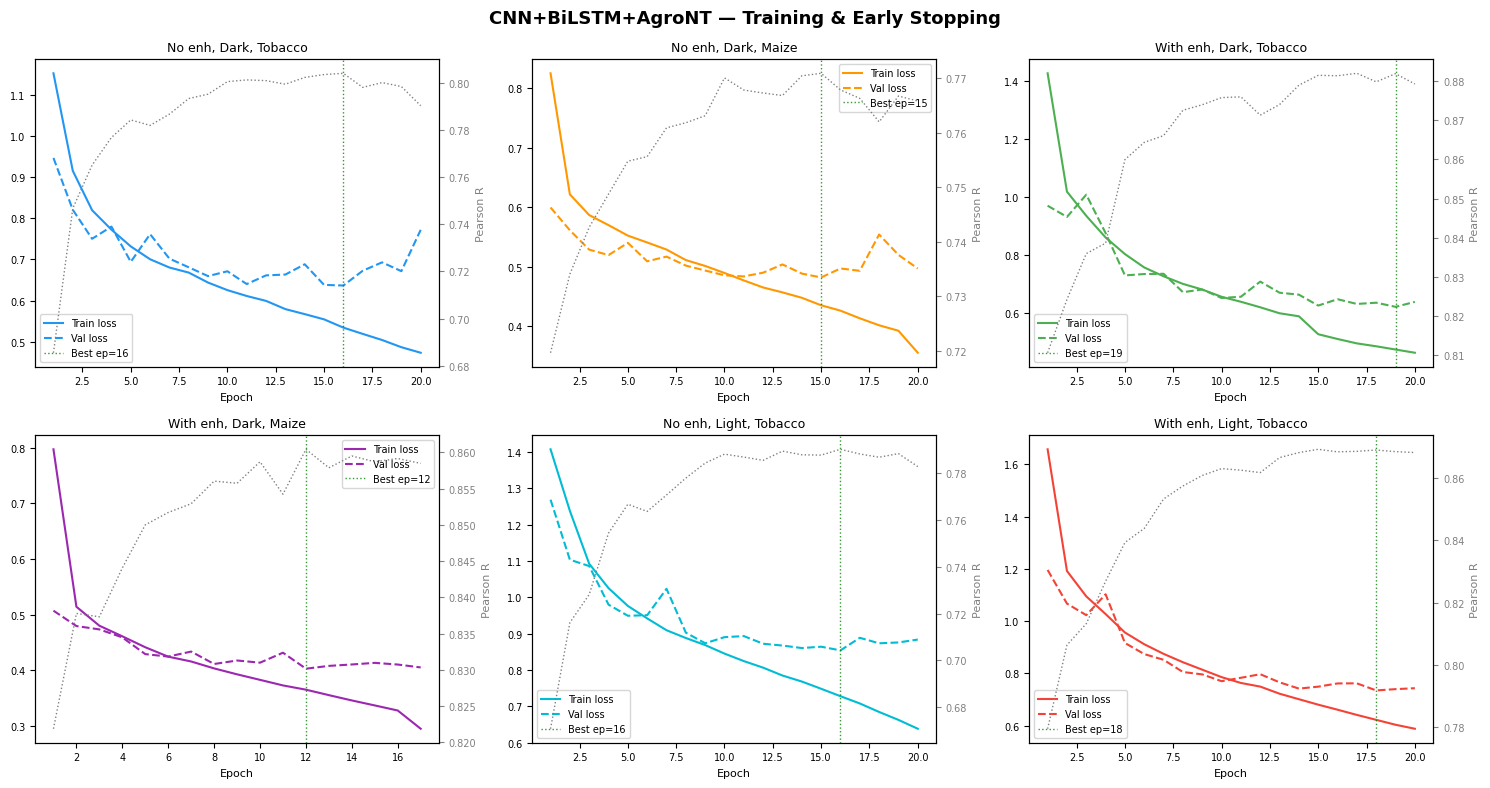

Saved: training_curves.png


In [ ]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
NUM_EPOCHS  = 20     # max — early stopping may trigger before this
ES_PATIENCE = 5      # stop if val_loss doesn't improve for 5 consecutive epochs
LR          = 1e-3

trained_models = {}; train_history = {}
COLORS_ = ["#2196F3","#FF9800","#4CAF50","#9C27B0","#00BCD4","#F44336"]

print(f"Training 6 hybrid models — max {NUM_EPOCHS} epochs, early-stop patience={ES_PATIENCE}\n")
print(f"{'Condition':<28} {'Ep':>3} {'TrLoss':>8} {'VaLoss':>8} {'ValR':>7} {'ES':>4}")
print("-"*62)

for col, label in zip(COND_COLS, COND_LABELS):
    model   = HybridPromoterModel(AGRO_HIDDEN_DIM).to(DEVICE)
    opt     = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    # ReduceLROnPlateau is compatible with early stopping (unlike OneCycleLR)
    sched   = torch.optim.lr_scheduler.ReduceLROnPlateau(
                  opt, mode="min", patience=3, factor=0.5, min_lr=1e-5)
    loss_fn = nn.MSELoss()
    scaler  = torch.cuda.amp.GradScaler()

    best_val, best_state = float("inf"), None
    patience_ctr = 0
    hist = {"train_loss":[], "val_loss":[], "val_r":[], "lr":[]}

    for ep in range(NUM_EPOCHS):
        # ── Train ────────────────────────────────────────────────────────────
        model.train(); trl = []
        for oh, lm, gc, sp, lab in datasets[col]["train"]:
            oh, lm, gc, sp, lab = (oh.to(DEVICE), lm.to(DEVICE), gc.to(DEVICE),
                                    sp.to(DEVICE), lab.to(DEVICE))
            opt.zero_grad()
            with torch.cuda.amp.autocast():
                loss = loss_fn(model(oh, lm, gc, sp), lab)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            trl.append(loss.item())

        # ── Validate ─────────────────────────────────────────────────────────
        model.eval(); val_l, pp, tt = [], [], []
        with torch.no_grad():
            for oh, lm, gc, sp, lab in datasets[col]["val"]:
                oh, lm, gc, sp, lab = (oh.to(DEVICE), lm.to(DEVICE), gc.to(DEVICE),
                                        sp.to(DEVICE), lab.to(DEVICE))
                pred = model(oh, lm, gc, sp)
                val_l.append(loss_fn(pred, lab).item())
                pp.extend(pred.cpu().numpy()); tt.extend(lab.cpu().numpy())

        tr_l  = np.mean(trl); va_l = np.mean(val_l); va_r, _ = pearsonr(tt, pp)
        cur_lr = opt.param_groups[0]["lr"]
        hist["train_loss"].append(tr_l); hist["val_loss"].append(va_l)
        hist["val_r"].append(va_r);      hist["lr"].append(cur_lr)

        sched.step(va_l)

        # ── Early stopping ────────────────────────────────────────────────────
        if va_l < best_val:
            best_val  = va_l
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if ep % 5 == 0 or ep == NUM_EPOCHS-1 or patience_ctr == ES_PATIENCE:
            print(f"{label:<28} {ep+1:>3} {tr_l:>8.4f} {va_l:>8.4f} {va_r:>7.3f} {patience_ctr:>4}")

        if patience_ctr >= ES_PATIENCE:
            print(f"  ⏹  Early stop at epoch {ep+1} — best val_loss={best_val:.4f}\n")
            break

    model.load_state_dict(best_state)
    trained_models[col] = model; train_history[col] = hist

print("All 6 hybrid models trained ✓")

# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8)); axes = axes.flatten()
fig.suptitle("CNN+BiLSTM+AgroNT — Training & Early Stopping", fontsize=13, fontweight="bold")
for i, (col, label, color) in enumerate(zip(COND_COLS, COND_LABELS, COLORS_)):
    ax   = axes[i]; hist = train_history[col]
    eps  = range(1, len(hist["train_loss"])+1)
    ax.plot(eps, hist["train_loss"], color=color, lw=1.5, label="Train loss")
    ax.plot(eps, hist["val_loss"],   color=color, lw=1.5, ls="--", label="Val loss")
    # Mark best epoch
    best_ep = int(np.argmin(hist["val_loss"]))+1
    ax.axvline(best_ep, color="green", ls=":", lw=1, alpha=0.8, label=f"Best ep={best_ep}")
    ax2 = ax.twinx()
    ax2.plot(eps, hist["val_r"], color="gray", lw=1, ls=":", label="Val R")
    ax2.set_ylabel("Pearson R", fontsize=8, color="gray"); ax2.tick_params(labelsize=7, colors="gray")
    ax.set_title(label, fontsize=9); ax.set_xlabel("Epoch", fontsize=8)
    ax.legend(fontsize=7); ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight"); plt.show()
print("Saved: training_curves.png")

## Cell 10 — Evaluate on test set

In [ ]:
results = {}
print(f"{'Condition':<28} {'Pearson R':>9} {'R²':>7} {'RMSE':>7}")
print("-" * 50)

for col, label in zip(COND_COLS, COND_LABELS):
    model = trained_models[col]; model.eval()
    pp, tt = [], []
    with torch.no_grad():
        for oh, lm, gc, sp, lab in datasets[col]["test"]:
            pred = model(oh.to(DEVICE), lm.to(DEVICE), gc.to(DEVICE), sp.to(DEVICE))
            pp.extend(pred.cpu().numpy()); tt.extend(lab.numpy())

    r,  _ = pearsonr(tt, pp)
    r2    = r2_score(tt, pp)
    rmse  = np.sqrt(mean_squared_error(tt, pp))
    results[col] = dict(r=r, r2=r2, rmse=rmse, pred=pp, true=tt)
    print(f"{label:<28} {r:>9.3f} {r2:>7.3f} {rmse:>7.3f}")

print("\nEvaluation complete ✓")

Condition                    Pearson R      R²    RMSE
--------------------------------------------------
No enh, Dark, Tobacco            0.808   0.651   0.790
No enh, Dark, Maize              0.776   0.600   0.700
With enh, Dark, Tobacco          0.879   0.772   0.811
With enh, Dark, Maize            0.869   0.754   0.619
No enh, Light, Tobacco           0.789   0.621   0.916
With enh, Light, Tobacco         0.868   0.752   0.867

Evaluation complete ✓


## Cell 11 — Performance visualisation

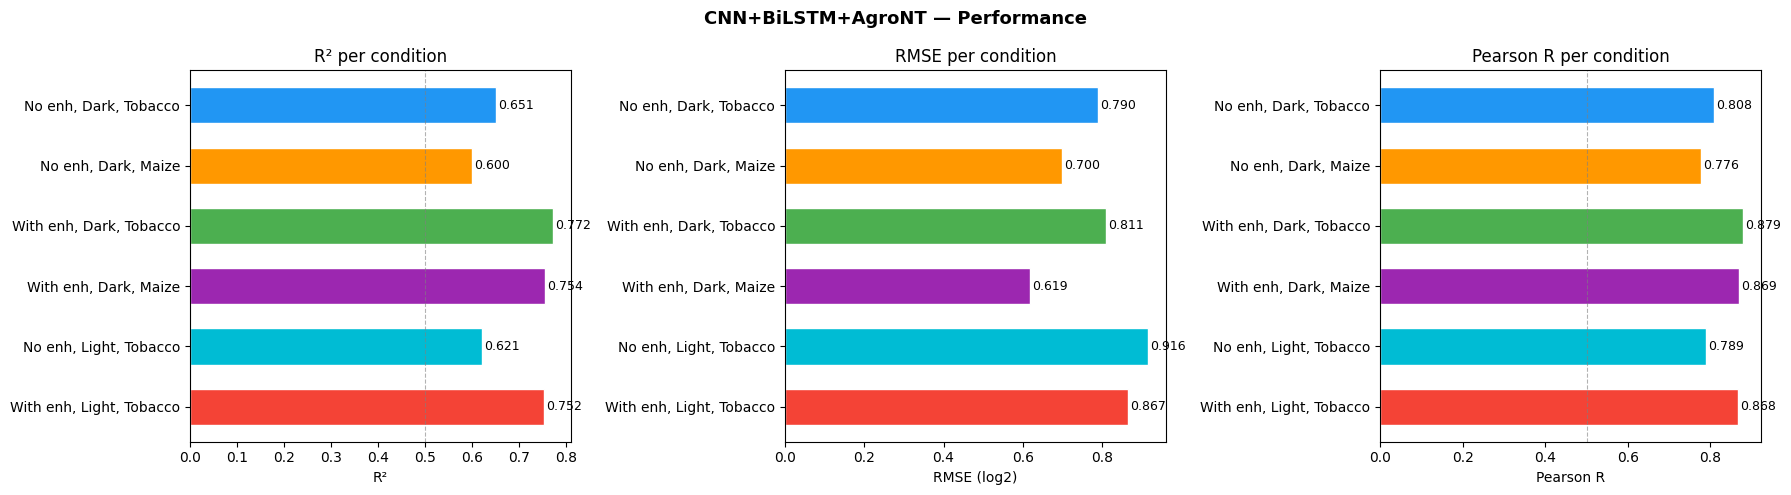

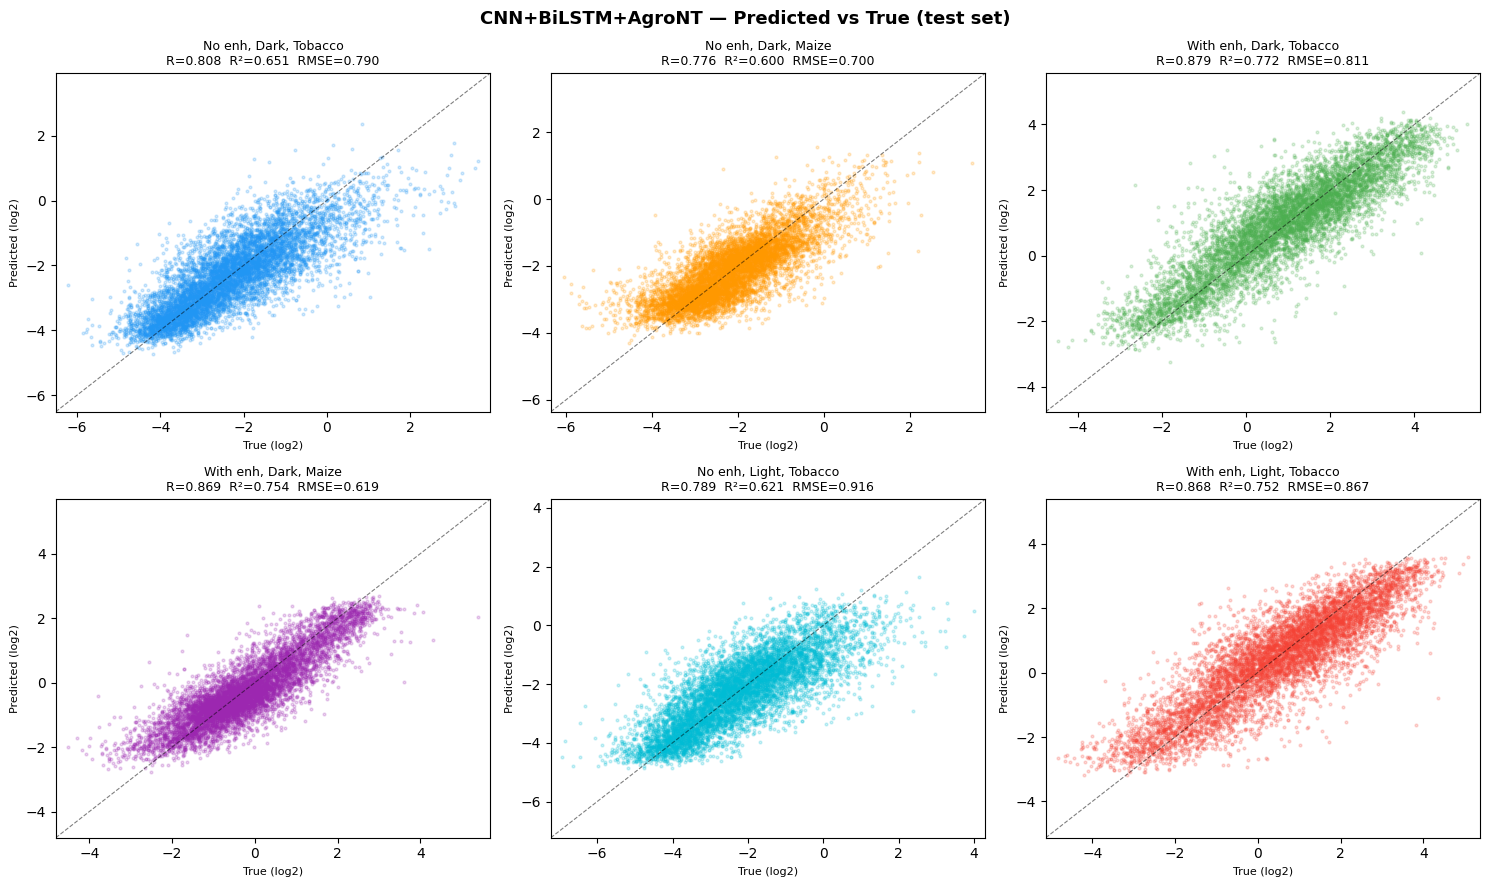

Saved: performance.png, scatter.png


In [ ]:
COLORS = ["#2196F3","#FF9800","#4CAF50","#9C27B0","#00BCD4","#F44336"]
r2_v   = [results[c]["r2"]   for c in COND_COLS]
rmse_v = [results[c]["rmse"] for c in COND_COLS]
r_v    = [results[c]["r"]    for c in COND_COLS]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("CNN+BiLSTM+AgroNT — Performance", fontsize=13, fontweight="bold")
for ax, vals, xlabel, title in zip(axes,
        [r2_v, rmse_v, r_v],
        ["R²","RMSE (log2)","Pearson R"],
        ["R² per condition","RMSE per condition","Pearson R per condition"]):
    bars = ax.barh(COND_LABELS, vals, color=COLORS, edgecolor="white", height=0.6)
    for bar, v in zip(bars, vals):
        ax.text(v+0.005, bar.get_y()+bar.get_height()/2, f"{v:.3f}", va="center", fontsize=9)
    if "RMSE" not in xlabel:
        ax.axvline(0.5, color="gray", ls="--", lw=0.8, alpha=0.6)
    ax.set_xlabel(xlabel); ax.set_title(title); ax.invert_yaxis()
plt.tight_layout(); plt.savefig("performance.png", dpi=150, bbox_inches="tight"); plt.show()

# Scatter
fig, axes = plt.subplots(2, 3, figsize=(15, 9)); axes = axes.flatten()
fig.suptitle("CNN+BiLSTM+AgroNT — Predicted vs True (test set)", fontsize=13, fontweight="bold")
for i, (col, label, color) in enumerate(zip(COND_COLS, COND_LABELS, COLORS)):
    ax = axes[i]; yt = results[col]["true"]; yp = results[col]["pred"]
    ax.scatter(yt, yp, alpha=0.2, s=4, color=color)
    lims = [min(min(yt),min(yp))-0.3, max(max(yt),max(yp))+0.3]
    ax.plot(lims, lims, "k--", lw=0.8, alpha=0.5)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(f"{label}\nR={results[col]['r']:.3f}  R²={results[col]['r2']:.3f}  RMSE={results[col]['rmse']:.3f}", fontsize=9)
    ax.set_xlabel("True (log2)", fontsize=8); ax.set_ylabel("Predicted (log2)", fontsize=8)
plt.tight_layout(); plt.savefig("scatter.png", dpi=150, bbox_inches="tight"); plt.show()
print("Saved: performance.png, scatter.png")

## Cell 12 — ISM + heatmaps + active regions

> **Updated:** ISM `predict()` now passes gc and species to model. GC recomputed per mutation.

Running ISM on 5 sequences (170 positions × 3 alts each)...
  [1/5] done in 30.5s
  [2/5] done in 30.4s
  [3/5] done in 30.2s
  [4/5] done in 30.4s
  [5/5] done in 30.3s
ISM complete ✓



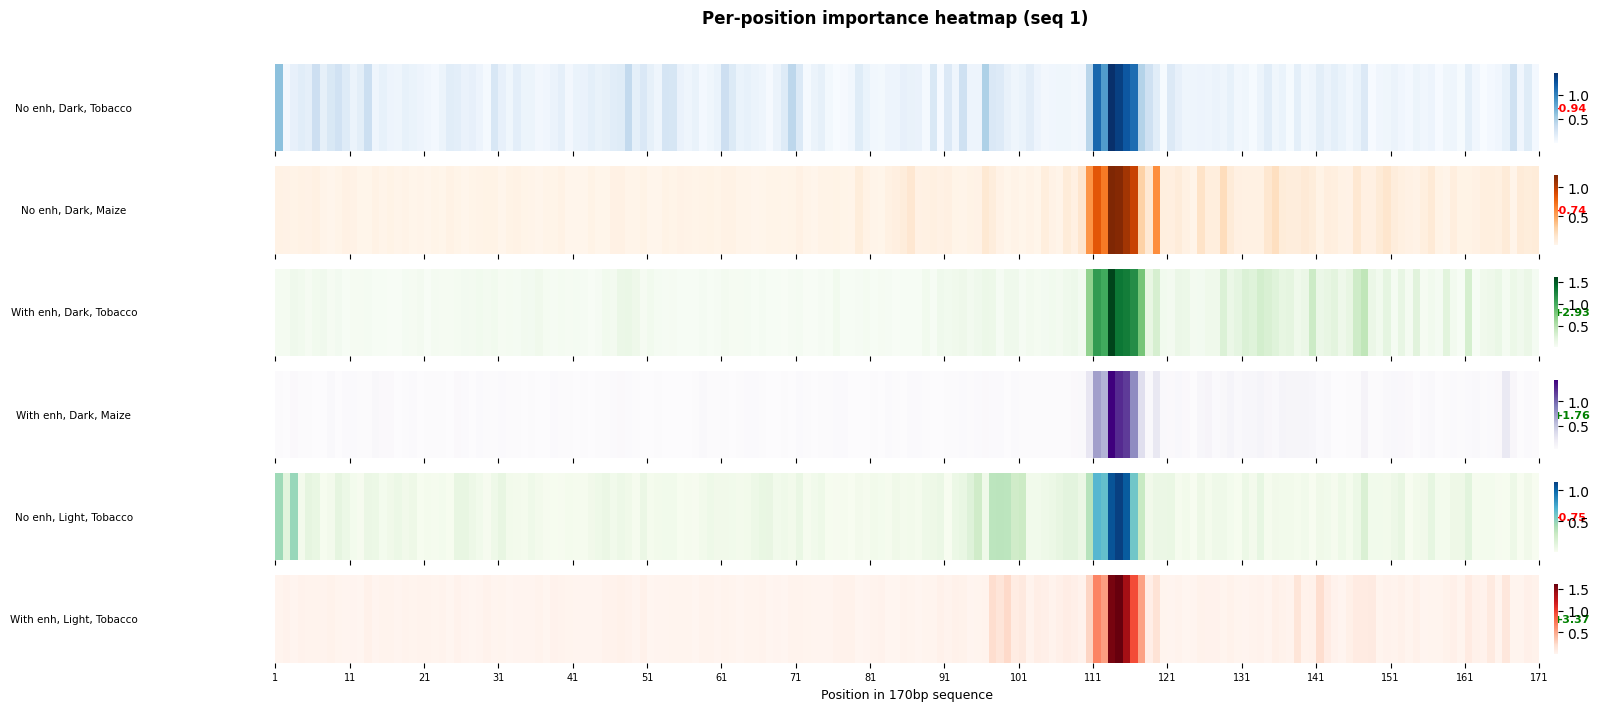

Saved: heatmap_seq1.png


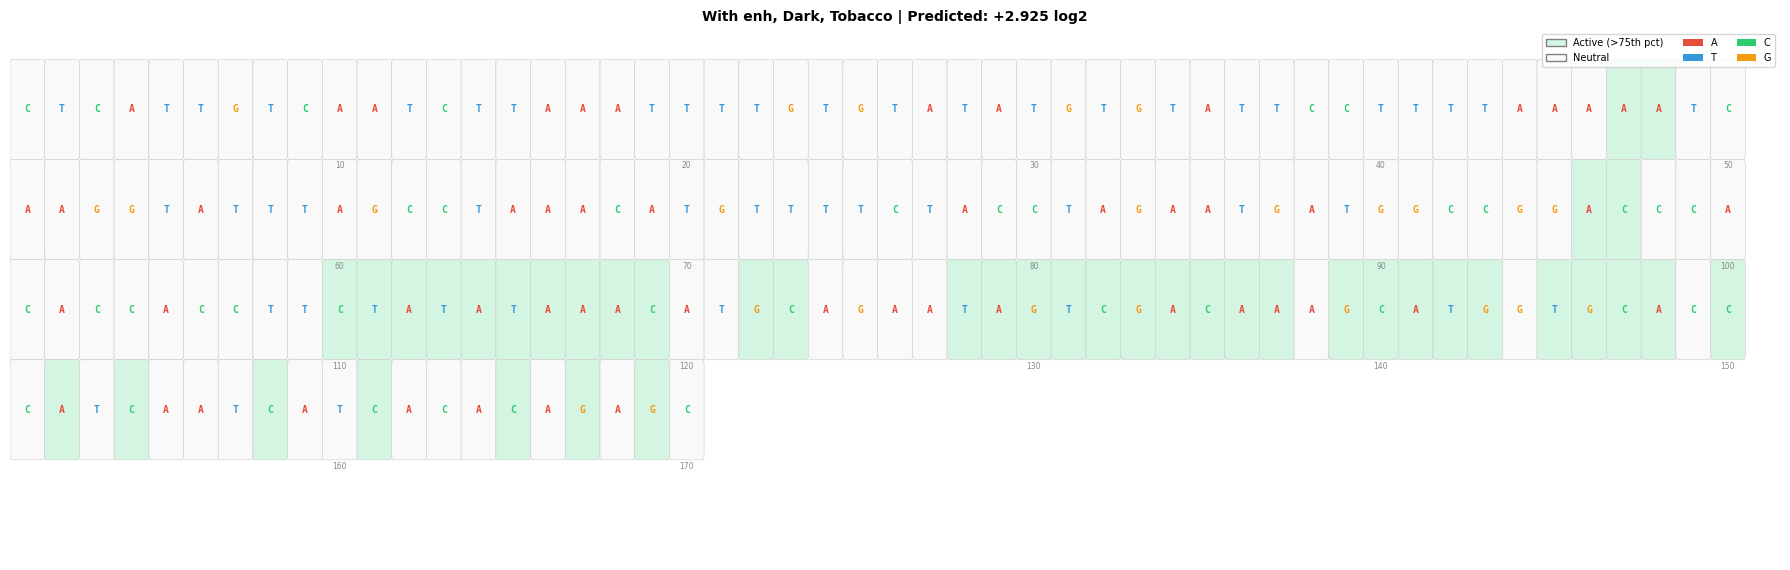

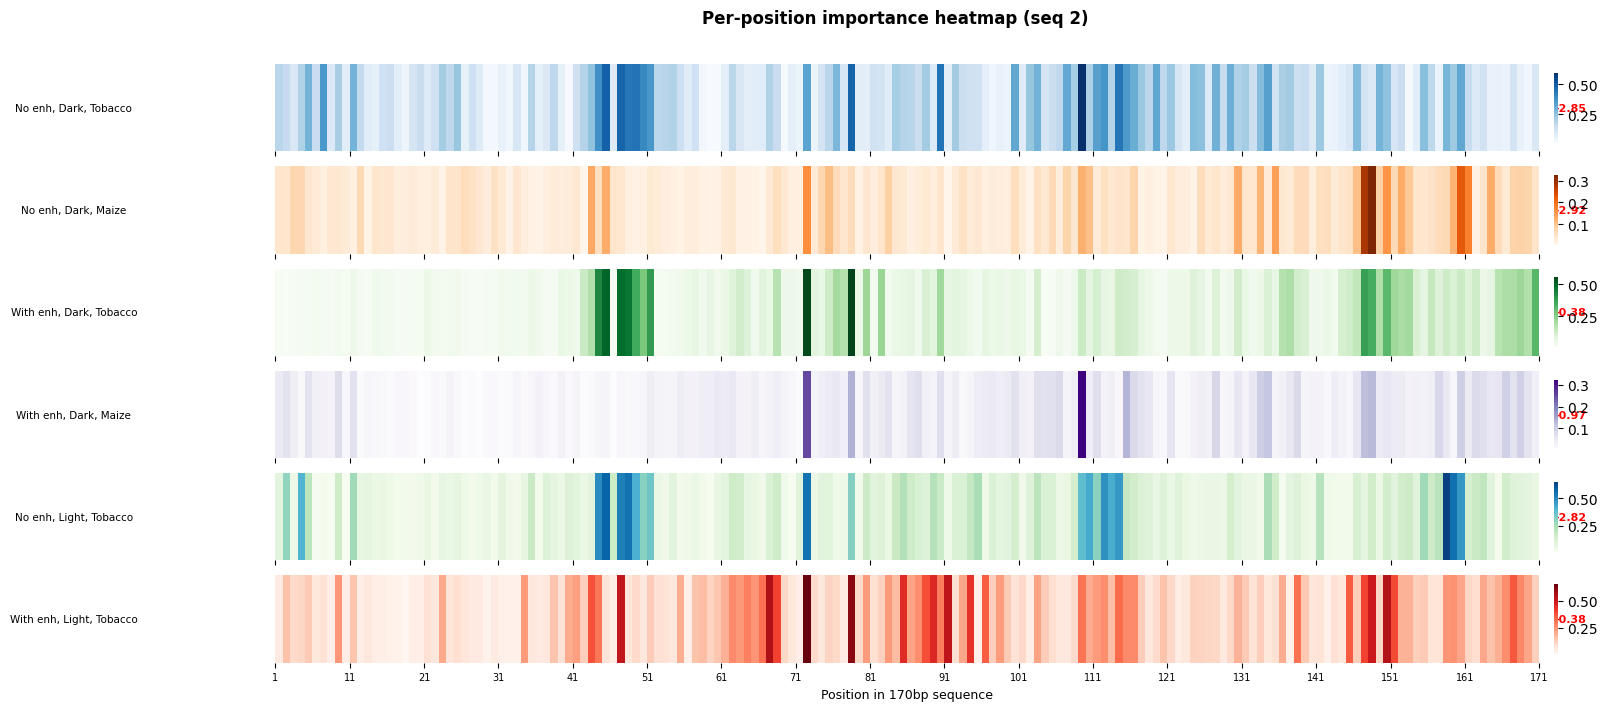

Saved: heatmap_seq2.png


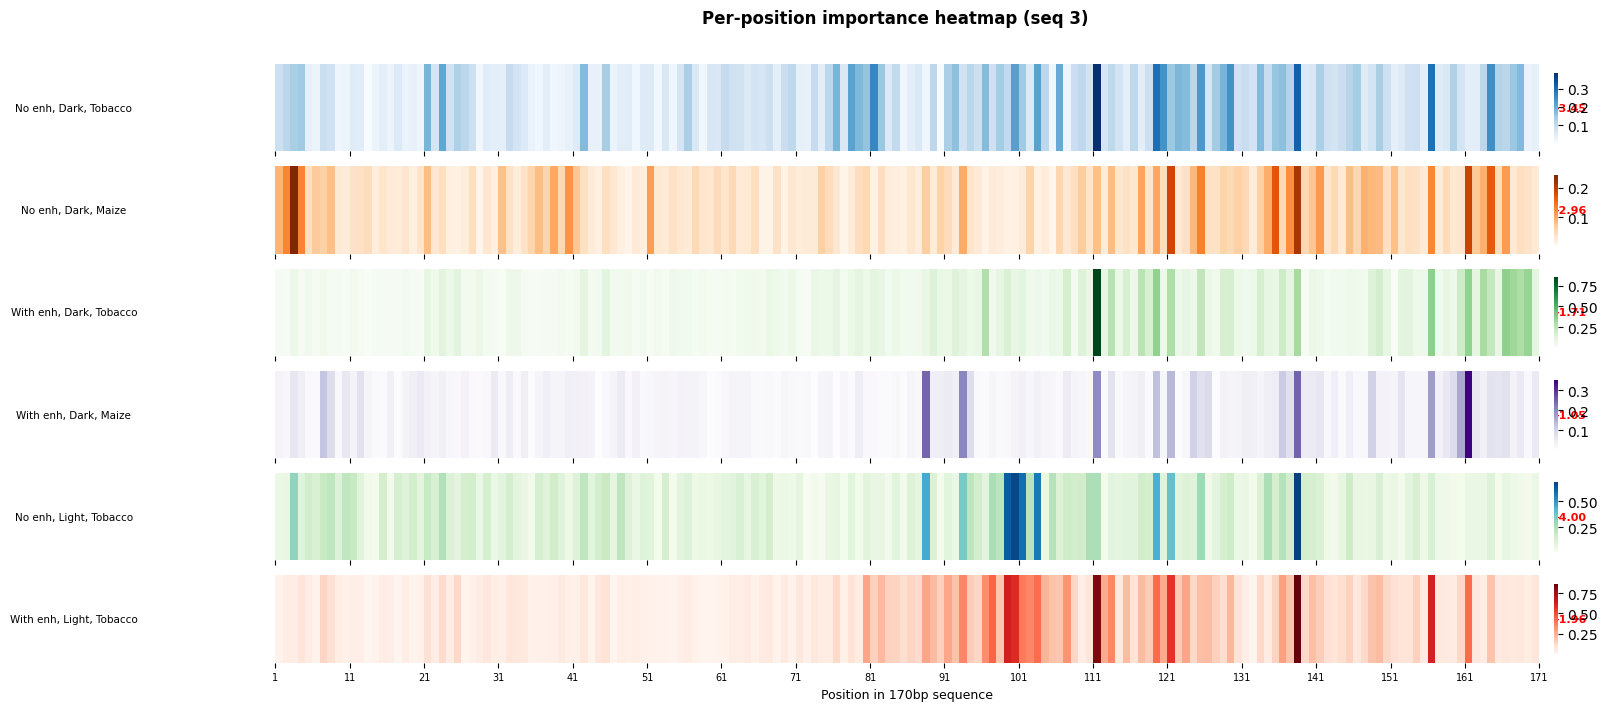

Saved: heatmap_seq3.png


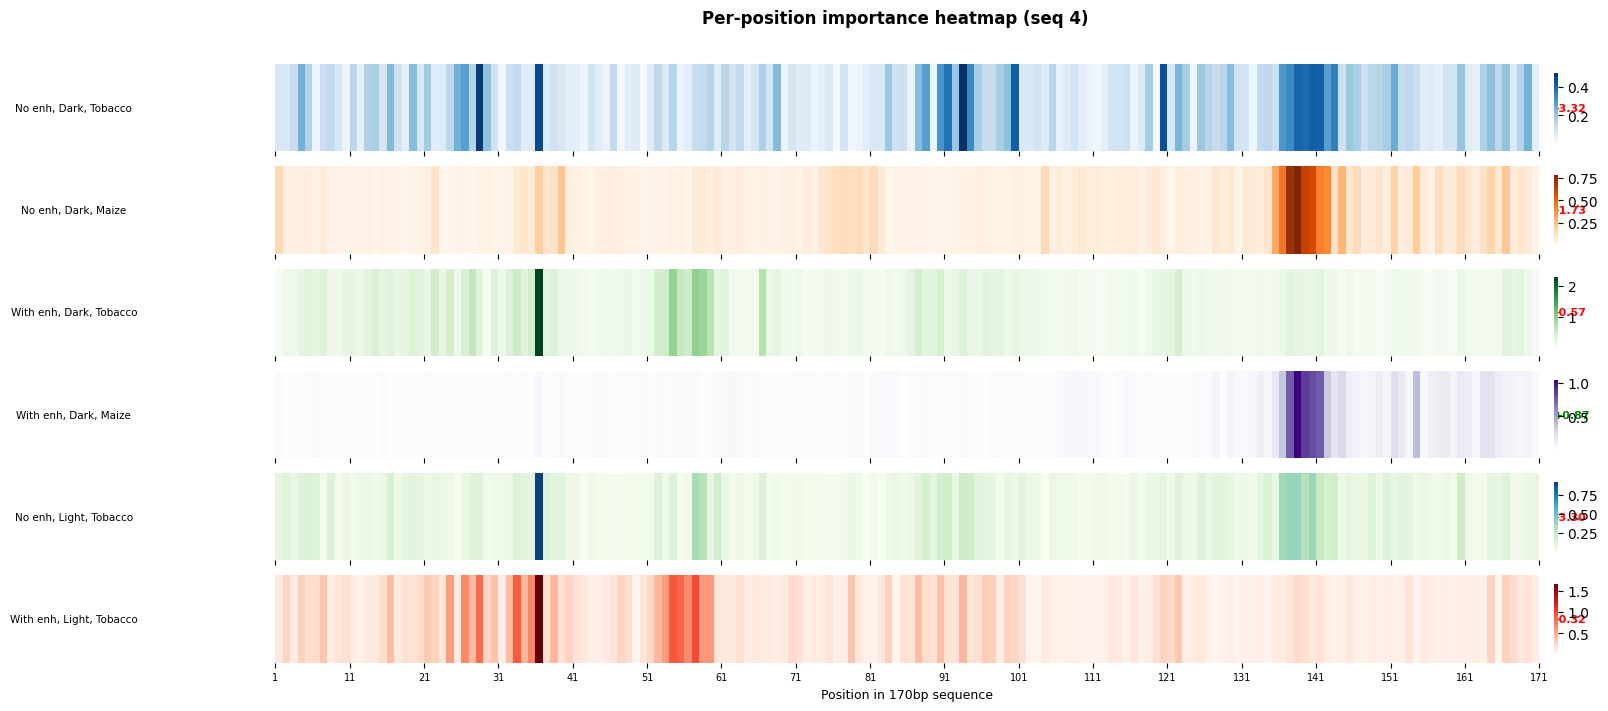

Saved: heatmap_seq4.png


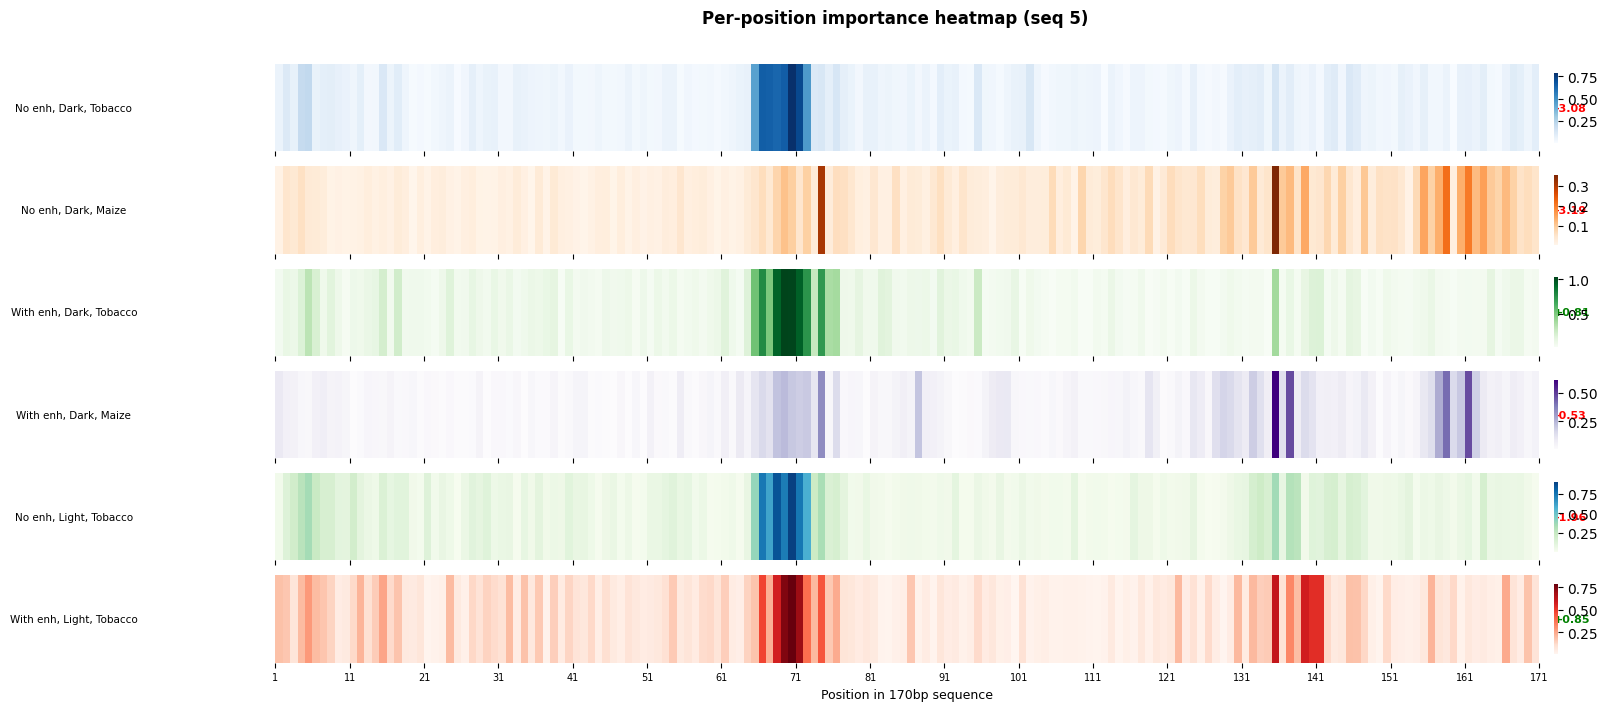

Saved: heatmap_seq5.png


,Condition,Start,End,Length,Subsequence,Importance,Predicted
0,"With enh, Dark, Tobacco",110,119,10,CTATATAAAC,0.9472,+2.925
1,"With enh, Dark, Tobacco",111,111,1,C,0.8540,-1.709
2,"No enh, Dark, Tobacco",110,119,10,CTATATAAAC,0.8501,-0.942
3,"With enh, Light, Tobacco",32,36,5,GCTAA,0.8196,-0.315
4,"With enh, Light, Tobacco",110,119,10,CTATATAAAC,0.7773,+3.370
5,"With enh, Dark, Tobacco",66,66,1,C,0.7072,-0.568
6,"With enh, Dark, Tobacco",52,59,8,GTTTAAAA,0.7012,-0.568
7,"No enh, Dark, Maize",109,119,11,TCTATATAAAC,0.7008,-0.745
8,"With enh, Dark, Tobacco",32,38,7,GCTAAAA,0.6716,-0.568
9,"With enh, Light, Tobacco",72,72,1,G,0.6558,-0.382


Saved: active_regions.csv (90 rows)


In [ ]:
@torch.no_grad()
def get_embedding(seq):
    """Return (1, AGRO_HIDDEN_DIM) tensor. Uses cache if available, else computes."""
    if seq.strip() in seq_to_emb:
        return seq_to_emb[seq.strip()].unsqueeze(0).to(DEVICE)
    tokens = tokenize_sequence(seq)
    ids  = tokens["input_ids"].to(DEVICE); mask = tokens["attention_mask"].to(DEVICE)
    with torch.cuda.amp.autocast():
        out = agro_encoder(input_ids=ids, attention_mask=mask)
    hidden = out.last_hidden_state.float(); mask_f = mask.unsqueeze(-1).float()
    return ((hidden * mask_f).sum(1) / mask_f.sum(1))

def compute_ism(seq, cond_cols, gc_val=None, species_val=None):
    """ISM: per-position |delta prediction| averaged over 3 alternative nucleotides."""
    if gc_val   is None: gc_val   = compute_gc(seq)
    if species_val is None: species_val = np.zeros(SPECIES_DIM, dtype=np.float32)
    base_emb = get_embedding(seq)

    def predict(s, emb, gc_v):
        oh   = torch.tensor(one_hot_encode(s)).unsqueeze(0).to(DEVICE)
        lm_e = emb
        gc_t = torch.tensor([[gc_v]], dtype=torch.float32).to(DEVICE)
        sp_t = torch.tensor(species_val).unsqueeze(0).to(DEVICE)
        return np.array([trained_models[c](oh, lm_e, gc_t, sp_t).item()
                         for c in cond_cols])

    base_preds = predict(seq, base_emb, gc_val)
    importance = np.zeros((len(seq), len(cond_cols)), dtype=np.float32)

    for pos in range(len(seq)):
        alts  = [nt for nt in "ATCG" if nt != seq[pos]]
        delta = np.zeros(len(cond_cols))
        for alt in alts:
            mut_seq = seq[:pos] + alt + seq[pos+1:]
            mut_emb = get_embedding(mut_seq)
            mut_gc  = compute_gc(mut_seq)     # GC changes with mutation
            delta  += np.abs(predict(mut_seq, mut_emb, mut_gc) - base_preds)
        importance[pos] = delta / len(alts)
    return importance, base_preds

def find_active_regions(imp_1d, pct=75):
    thresh = np.percentile(imp_1d, pct); active = imp_1d > thresh
    regions, in_r, start = [], False, 0
    for i, a in enumerate(active):
        if a and not in_r: start, in_r = i, True
        elif not a and in_r: regions.append((start, i-1, float(imp_1d[start:i].mean()))); in_r = False
    if in_r: regions.append((start, len(active)-1, float(imp_1d[start:].mean())))
    return sorted(regions, key=lambda x: -x[2])[:3]

NT_COLORS = {"A":"#e74c3c","T":"#3498db","C":"#2ecc71","G":"#f39c12"}
CMAPS     = ["Blues","Oranges","Greens","Purples","GnBu","Reds"]

def plot_heatmap(res, idx):
    imp = res["importance"]; pred = res["predictions"]
    fig, axes = plt.subplots(6, 1, figsize=(18, 7), sharex=True)
    fig.suptitle(f"Per-position importance heatmap (seq {idx+1})", fontsize=12, fontweight="bold", y=1.01)
    for c, (ax, label, cmap) in enumerate(zip(axes, COND_LABELS, CMAPS)):
        sns.heatmap(imp[:,c].reshape(1,-1), ax=ax, cmap=cmap, cbar=True,
                    cbar_kws={"shrink":0.8,"pad":0.01}, xticklabels=False, yticklabels=False)
        val = pred[c]; color = "green" if val >= 0 else "red"
        ax.set_ylabel(label, fontsize=7.5, rotation=0, labelpad=145, va="center")
        ax.text(172, 0.5, f"{val:+.2f}", transform=ax.transData, fontsize=8, va="center",
                color=color, fontweight="bold")
    axes[-1].set_xlabel("Position in 170bp sequence", fontsize=9)
    axes[-1].set_xticks(range(0,171,10)); axes[-1].set_xticklabels(range(1,172,10), fontsize=7)
    plt.tight_layout(); plt.savefig(f"heatmap_seq{idx+1}.png", dpi=150, bbox_inches="tight"); plt.show()
    print(f"Saved: heatmap_seq{idx+1}.png")

def plot_seq_view(res, cond_idx=2):
    seq = res["sequence"]; imp = res["importance"][:,cond_idx]
    thresh = np.percentile(imp, 75); label = COND_LABELS[cond_idx]; pv = res["predictions"][cond_idx]
    cols_per_row = 50; n_rows = -(-len(seq)//cols_per_row)
    fig, ax = plt.subplots(figsize=(18, 1.2*n_rows+1)); ax.axis("off")
    ax.set_xlim(-0.5, cols_per_row+0.5); ax.set_ylim(-n_rows-0.5, 0.8)
    ax.set_title(f"{label} | Predicted: {pv:+.3f} log2", fontsize=10, fontweight="bold")
    for i, (nt, im) in enumerate(zip(seq, imp)):
        col = i%cols_per_row; row = -(i//cols_per_row)
        bg = "#d5f5e3" if im > thresh else "#f9f9f9"
        ax.add_patch(FancyBboxPatch((col-0.45,row-0.45), 0.9, 0.9, boxstyle="round,pad=0.05",
                     facecolor=bg, edgecolor="#cccccc", linewidth=0.4))
        ax.text(col, row, nt, ha="center", va="center", fontsize=7, fontweight="bold",
                color=NT_COLORS.get(nt,"black"), fontfamily="monospace")
        if (i+1)%10==0: ax.text(col, row-0.52, str(i+1), ha="center", va="top", fontsize=5.5, color="#888")
    legend_elements = ([Patch(facecolor="#d5f5e3",edgecolor="gray",label="Active (>75th pct)"),
                        Patch(facecolor="#f9f9f9",edgecolor="gray",label="Neutral")]
                       + [Patch(facecolor=c,label=n) for n,c in NT_COLORS.items()])
    ax.legend(handles=legend_elements, loc="upper right", fontsize=7, ncol=3)
    plt.tight_layout(); plt.savefig(f"seqview_cond{cond_idx}.png", dpi=150, bbox_inches="tight"); plt.show()

# ── Run ISM ────────────────────────────────────────────────────────────────────
N_GENES = 5
sample_idx   = list(range(N_GENES))
test_seqs_s  = datasets[COND_COLS[0]]["test_seqs"][:N_GENES]
test_gc_s    = datasets[COND_COLS[0]]["test_gc"][:N_GENES]
test_sp_s    = datasets[COND_COLS[0]]["test_sp"][:N_GENES]

ism_results = []
print(f"Running ISM on {N_GENES} sequences ({SEQ_LEN} positions × 3 alts each)...")
for j, (seq, gc_v, sp_v) in enumerate(zip(test_seqs_s, test_gc_s, test_sp_s)):
    t0 = time.time()
    imp, preds = compute_ism(seq, COND_COLS, gc_v, encode_species(sp_v))
    ism_results.append({"sequence":seq,"importance":imp,"predictions":preds})
    print(f"  [{j+1}/{N_GENES}] done in {time.time()-t0:.1f}s")
print("ISM complete ✓\n")

for idx, res in enumerate(ism_results):
    plot_heatmap(res, idx)
    if idx == 0: plot_seq_view(res, cond_idx=2)

# Active regions table
rows = []
for res in ism_results:
    for ci, col in enumerate(COND_COLS):
        for start, end, score in find_active_regions(res["importance"][:,ci]):
            rows.append({"Condition":COND_LABELS[ci],"Start":start+1,"End":end+1,
                          "Length":end-start+1,"Subsequence":res["sequence"][start:end+1],
                          "Importance":round(score,4),"Predicted":round(res["predictions"][ci],3)})
summary_df = pd.DataFrame(rows).sort_values("Importance",ascending=False).reset_index(drop=True)
display(summary_df.style
        .applymap(lambda v: f"background-color:{'#c8e6c9' if v>=0 else '#ffcdd2'}", subset=["Predicted"])
        .format({"Importance":"{:.4f}","Predicted":"{:+.3f}"})
        .set_caption("Active regions per sequence per condition"))
summary_df.to_csv("active_regions.csv", index=False)
print(f"Saved: active_regions.csv ({len(summary_df)} rows)")

## Cell 12b — Position-zone clustering + motif density + cross-condition heatmap

> **New:** Zone importance (Early/Middle/Late) · Per-condition density curves · Conserved vs condition-specific positions.

Position-zone analysis on ISM results...

       Early (1-50)|No enh, Dark, Tobacco  Early (1-50)|No enh, Dark, Maize  Early (1-50)|With enh, Dark, Tobacco  Early (1-50)|With enh, Dark, Maize  Early (1-50)|No enh, Light, Tobacco  Early (1-50)|With enh, Light, Tobacco  Middle (51-100)|No enh, Dark, Tobacco  Middle (51-100)|No enh, Dark, Maize  Middle (51-100)|With enh, Dark, Tobacco  Middle (51-100)|With enh, Dark, Maize  Middle (51-100)|No enh, Light, Tobacco  Middle (51-100)|With enh, Light, Tobacco  Late (101-170)|No enh, Dark, Tobacco  Late (101-170)|No enh, Dark, Maize  Late (101-170)|With enh, Dark, Tobacco  Late (101-170)|With enh, Dark, Maize  Late (101-170)|No enh, Light, Tobacco  Late (101-170)|With enh, Light, Tobacco
Seq 1                              0.1459                            0.0246                                0.0495                              0.0233                               0.0761                                 0.0213                                 0.13

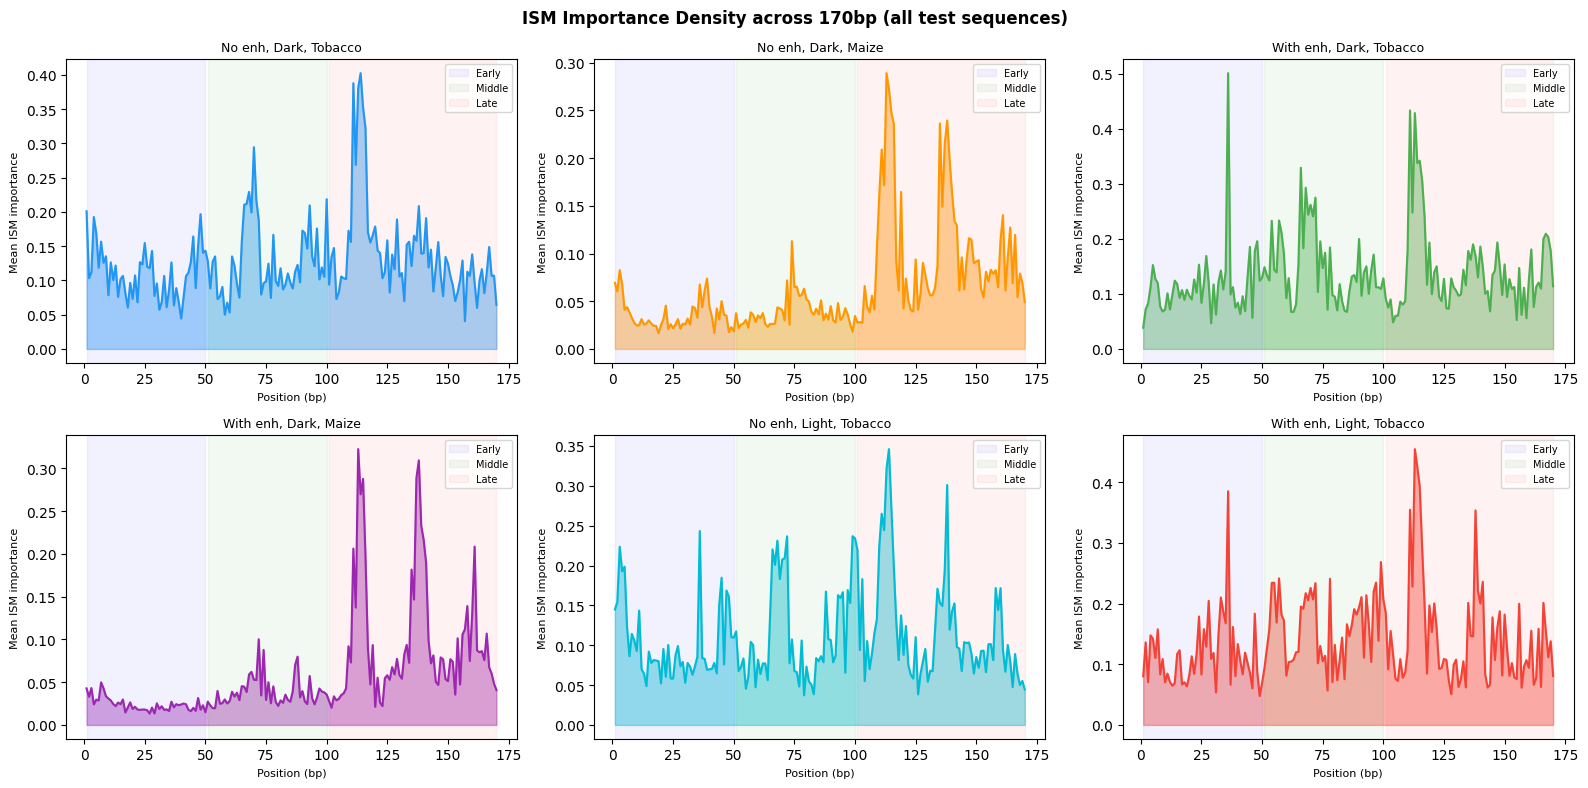

Saved: motif_density.png


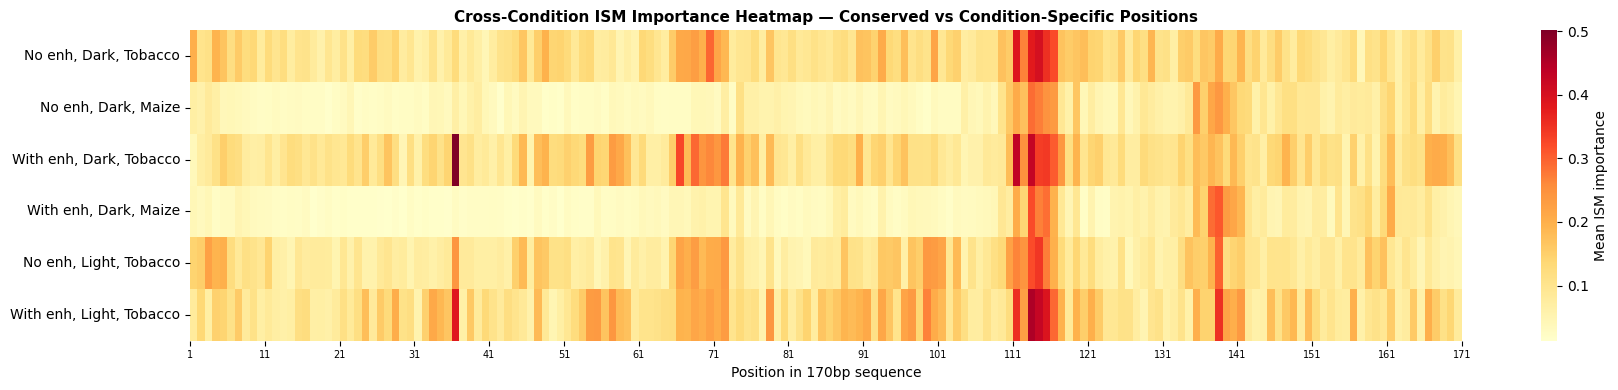

Top 10 conserved positions (consistent across all 6 conds): [136, 162, 144, 163, 132, 142, 154, 77, 151, 39]
Top 10 condition-specific positions (high variance):        [100, 71, 57, 54, 111, 68, 99, 70, 66, 36]
Saved: cross_condition_importance.png


In [ ]:
# ── Position-zone clustering + motif density + cross-condition heatmap ────────
print("Position-zone analysis on ISM results...\n")

ZONES = {"Early (1-50)": (0,50), "Middle (51-100)": (50,100), "Late (101-170)": (100,170)}
zone_profiles = []
for res in ism_results:
    imp = res["importance"]   # (170, 6)
    row = {}
    for zname, (zs, ze) in ZONES.items():
        for ci, cl in enumerate(COND_LABELS):
            row[f"{zname}|{cl}"] = float(imp[zs:ze, ci].mean())
    zone_profiles.append(row)
zone_df = pd.DataFrame(zone_profiles, index=[f"Seq {i+1}" for i in range(len(ism_results))])
print(zone_df.round(4).to_string())

# ── Motif density (KDE) per condition ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
fig.suptitle("ISM Importance Density across 170bp (all test sequences)", fontsize=12, fontweight="bold")
COLORS = ["#2196F3","#FF9800","#4CAF50","#9C27B0","#00BCD4","#F44336"]
for ci, (col, label, color) in enumerate(zip(COND_COLS, COND_LABELS, COLORS)):
    ax = axes[ci]
    all_imp = np.stack([r["importance"][:, ci] for r in ism_results])  # (N, 170)
    mean_imp = all_imp.mean(axis=0)
    ax.fill_between(range(1, SEQ_LEN+1), mean_imp, alpha=0.4, color=color)
    ax.plot(range(1, SEQ_LEN+1), mean_imp, color=color, lw=1.5)
    ax.axvspan(1,  50,  alpha=0.05, color="blue",  label="Early")
    ax.axvspan(51, 100, alpha=0.05, color="green", label="Middle")
    ax.axvspan(101,170, alpha=0.05, color="red",   label="Late")
    ax.set_title(label, fontsize=9); ax.set_xlabel("Position (bp)", fontsize=8)
    ax.set_ylabel("Mean ISM importance", fontsize=8); ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig("motif_density.png", dpi=150, bbox_inches="tight"); plt.show()
print("Saved: motif_density.png")

# ── Cross-condition importance heatmap ────────────────────────────────────────
mean_imp_matrix = np.stack([
    np.stack([r["importance"][:,ci] for r in ism_results]).mean(axis=0)
    for ci in range(len(COND_COLS))
])   # (6, 170)

fig, ax = plt.subplots(figsize=(18, 4))
sns.heatmap(mean_imp_matrix, ax=ax, cmap="YlOrRd", cbar_kws={"label":"Mean ISM importance"},
            xticklabels=10, yticklabels=COND_LABELS, linewidths=0)
ax.set_xlabel("Position in 170bp sequence", fontsize=10)
ax.set_title("Cross-Condition ISM Importance Heatmap — Conserved vs Condition-Specific Positions",
             fontsize=11, fontweight="bold")
ax.set_xticks(range(0,171,10)); ax.set_xticklabels(range(1,172,10), rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig("cross_condition_importance.png", dpi=150, bbox_inches="tight"); plt.show()

# Conserved vs condition-specific positions
importance_std = mean_imp_matrix.std(axis=0)    # low std = conserved across conditions
importance_mean = mean_imp_matrix.mean(axis=0)
top_conserved   = np.argsort(importance_std)[:10] + 1      # positions with lowest variance
top_specific    = np.argsort(importance_std)[-10:] + 1     # positions with highest variance
print(f"Top 10 conserved positions (consistent across all 6 conds): {top_conserved.tolist()}")
print(f"Top 10 condition-specific positions (high variance):        {top_specific.tolist()}")
print("Saved: cross_condition_importance.png")

## Cell 12c — TATA-box Positional Insertion (EUGENe Fig. 2f)

> Insert TATA-box consensus at every position across 100 test sequences.
> A position-sensitive model should predict highest activity when TATA lands
> at bp 120–145 (the biological TATA-box zone). EUGENe reported +147% increase
> on the same dataset.

EUGENe Analysis 1/5 — TATA-box Positional Insertion
EUGENe Fig. 2f: insert TATA motif at every position, measure
predicted activity. Should peak at TATA-box zone (bp 120-145).

Baseline mean activity: +0.995
Scanning 52 positions x 100 sequences...

Scan complete ✓


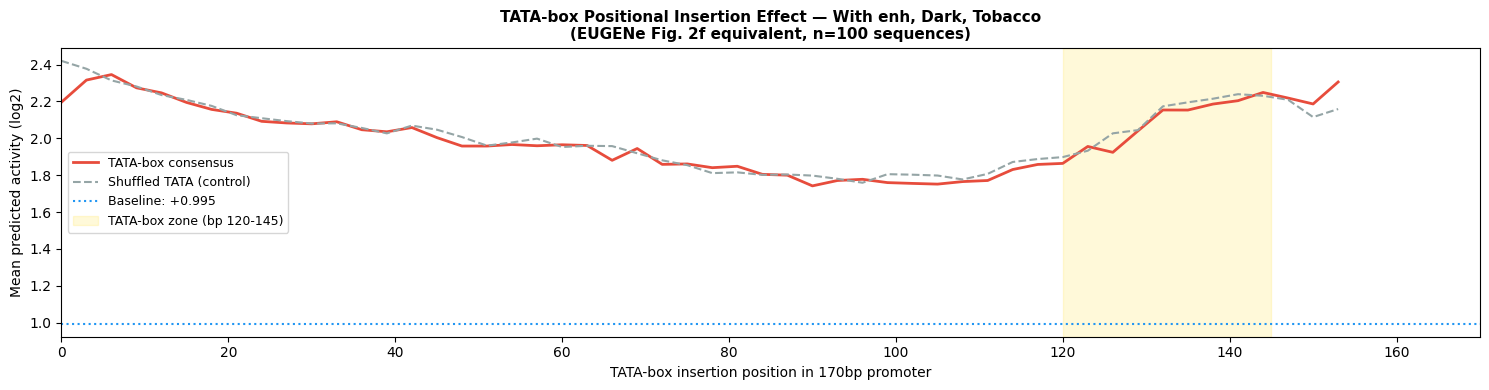


Results:
  TATA peak: +2.346 at bp 6
  Shuffled mean: +2.018
  Activity increase vs shuffled: +16.3%  (EUGENe reported +147%)
Saved: tata_insertion_positional.png ✓


In [ ]:
# ── TATA-box Positional Insertion ────────────────────────────────────────────
print("EUGENe Analysis 1/5 — TATA-box Positional Insertion")
print("="*60)
print("EUGENe Fig. 2f: insert TATA motif at every position, measure")
print("predicted activity. Should peak at TATA-box zone (bp 120-145).\n")

TATA_MOTIF     = "TATAAAAGATATAAA"   # 15bp plant TATA-box consensus
SHUFFLED_MOTIF = "AATGATATATAAAGA"   # shuffled negative control
MOTIF_LEN      = len(TATA_MOTIF)

N_INS_SEQS  = 100
cond_idx_t  = 2   # With enh, Dark, Tobacco (highest R²)
model_tata  = trained_models[COND_COLS[cond_idx_t]]
model_tata.eval()

ins_seqs = datasets[COND_COLS[cond_idx_t]]["test_seqs"][:N_INS_SEQS]
ins_gc   = datasets[COND_COLS[cond_idx_t]]["test_gc"][:N_INS_SEQS]
ins_sp   = [encode_species(s) for s in datasets[COND_COLS[cond_idx_t]]["test_sp"][:N_INS_SEQS]]

def predict_seq(seq, gc_v, sp_v, model):
    emb = get_embedding(seq)
    oh  = torch.tensor(one_hot_encode(seq)).unsqueeze(0).to(DEVICE)
    gc_t = torch.tensor([[compute_gc(seq)]], dtype=torch.float32).to(DEVICE)
    sp_t = torch.tensor(sp_v).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        return model(oh, emb, gc_t, sp_t).item()

# Baseline — original sequences
baseline = np.mean([predict_seq(s, g, p, model_tata)
                    for s,g,p in zip(ins_seqs, ins_gc, ins_sp)])
print(f"Baseline mean activity: {baseline:+.3f}")

positions_t = list(range(0, SEQ_LEN - MOTIF_LEN + 1, 3))
tata_means, shuf_means = [], []

print(f"Scanning {len(positions_t)} positions x {N_INS_SEQS} sequences...")
for pi, pos in enumerate(positions_t):
    t_preds, s_preds = [], []
    for seq, gc_v, sp_v in zip(ins_seqs, ins_gc, ins_sp):
        t_seq = seq[:pos] + TATA_MOTIF     + seq[pos+MOTIF_LEN:]
        s_seq = seq[:pos] + SHUFFLED_MOTIF + seq[pos+MOTIF_LEN:]
        t_preds.append(predict_seq(t_seq, gc_v, sp_v, model_tata))
        s_preds.append(predict_seq(s_seq, gc_v, sp_v, model_tata))
    tata_means.append(np.mean(t_preds))
    shuf_means.append(np.mean(s_preds))
    if (pi+1) % 10 == 0: print(f"  {pi+1}/{len(positions_t)} done...", end="\r")

tata_means = np.array(tata_means)
shuf_means = np.array(shuf_means)
print("\nScan complete ✓")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(positions_t, tata_means, color="#e74c3c", lw=2,   label="TATA-box consensus")
ax.plot(positions_t, shuf_means, color="#95a5a6", lw=1.5, ls="--", label="Shuffled TATA (control)")
ax.axhline(baseline, color="#2196F3", lw=1.5, ls=":", label=f"Baseline: {baseline:+.3f}")
ax.axvspan(120, 145, alpha=0.15, color="gold", label="TATA-box zone (bp 120-145)")
ax.set_xlabel("TATA-box insertion position in 170bp promoter", fontsize=10)
ax.set_ylabel("Mean predicted activity (log2)", fontsize=10)
ax.set_title(f"TATA-box Positional Insertion Effect — {COND_LABELS[cond_idx_t]}\n"
             f"(EUGENe Fig. 2f equivalent, n={N_INS_SEQS} sequences)", fontsize=11, fontweight="bold")
ax.legend(fontsize=9); ax.set_xlim(0, SEQ_LEN)
plt.tight_layout()
plt.savefig("tata_insertion_positional.png", dpi=150, bbox_inches="tight"); plt.show()

peak_pos = positions_t[np.argmax(tata_means)]
peak_val = tata_means.max()
shuf_m   = shuf_means.mean()
pct      = (peak_val - shuf_m) / abs(shuf_m) * 100 if shuf_m != 0 else 0
print(f"\nResults:")
print(f"  TATA peak: {peak_val:+.3f} at bp {peak_pos}")
print(f"  Shuffled mean: {shuf_m:+.3f}")
print(f"  Activity increase vs shuffled: {pct:+.1f}%  (EUGENe reported +147%)")
print("Saved: tata_insertion_positional.png ✓")

## Cell 12d — In-silico Sequence Evolution (EUGENe Fig. 2g)

> Greedy evolution: at each round, find the single-nucleotide mutation that
> maximally increases predicted activity and apply it. Repeat 10 rounds.
> EUGENe: 'almost all starting promoters showed notable increase after 3 mutations.'

In [ ]:
"""
# ── In-silico Sequence Evolution ─────────────────────────────────────────────
print("EUGENe Analysis 2/5 — In-silico Sequence Evolution")
print("="*60)
print("EUGENe Fig. 2g: greedy single-nt evolution, 10 rounds.")
print("At each round: try all ~510 mutations, apply best one.\n")

N_EVO_SEQS  = 20
N_ROUNDS    = 10
cond_idx_e  = 2   # With enh, Dark, Tobacco

evo_seqs = datasets[COND_COLS[cond_idx_e]]["test_seqs"][:N_EVO_SEQS]
evo_gc   = datasets[COND_COLS[cond_idx_e]]["test_gc"][:N_EVO_SEQS]
evo_sp   = [encode_species(s) for s in datasets[COND_COLS[cond_idx_e]]["test_sp"][:N_EVO_SEQS]]
model_ev = trained_models[COND_COLS[cond_idx_e]]

def greedy_evolve(seq, gc_v, sp_v, model, n_rounds=10):
    BASES = "ACGT"
    current = seq
    scores  = [predict_seq(current, gc_v, sp_v, model)]
    for _ in range(n_rounds):
        best_delta, best_seq = -np.inf, current
        for pos in range(SEQ_LEN):
            for nt in BASES:
                if nt == current[pos]: continue
                mut = current[:pos] + nt + current[pos+1:]
                s   = predict_seq(mut, compute_gc(mut), sp_v, model)
                if s - scores[-1] > best_delta:
                    best_delta, best_seq = s - scores[-1], mut
        current = best_seq
        scores.append(predict_seq(current, compute_gc(current), sp_v, model))
    return scores

print(f"Evolving {N_EVO_SEQS} sequences for {N_ROUNDS} rounds each...")
print("(~2-3 min total)\n")
all_scores = []
for i, (seq, gc_v, sp_v) in enumerate(zip(evo_seqs, evo_gc, evo_sp)):
    s = greedy_evolve(seq, gc_v, sp_v, model_ev, N_ROUNDS)
    all_scores.append(s)
    print(f"  [{i+1:2d}/{N_EVO_SEQS}] start={s[0]:+.3f}  r3={s[3]:+.3f}  "
          f"final={s[-1]:+.3f}  gain={s[-1]-s[0]:+.3f}")

all_scores = np.array(all_scores)   # (N_EVO_SEQS, N_ROUNDS+1)

# ── Plot ──────────────────────────────────────────────────────────────────────
rounds_x = list(range(N_ROUNDS + 1))
fig, ax  = plt.subplots(figsize=(10, 5))
for i in range(N_EVO_SEQS):
    ax.plot(rounds_x, all_scores[i], color="#90CAF9", alpha=0.4, lw=1)
mean_s = all_scores.mean(axis=0)
std_s  = all_scores.std(axis=0)
ax.plot(rounds_x, mean_s, color="#1565C0", lw=2.5, label="Mean score", zorder=5)
ax.fill_between(rounds_x, mean_s-std_s, mean_s+std_s,
                alpha=0.2, color="#1565C0", label="±1 std")
ax.axhline(mean_s[0], color="red", ls="--", lw=1.2,
           label=f"Starting mean: {mean_s[0]:+.3f}")
ax.set_xlabel("Evolution round", fontsize=11)
ax.set_ylabel("Predicted activity (log2)", fontsize=11)
ax.set_title(f"In-silico Sequence Evolution — {N_EVO_SEQS} Promoters\n"
             f"Condition: {COND_LABELS[cond_idx_e]}  (EUGENe Fig. 2g equivalent)",
             fontsize=11, fontweight="bold")
ax.set_xticks(rounds_x); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("insilico_evolution.png", dpi=150, bbox_inches="tight"); plt.show()

n_r3 = (all_scores[:,3] > all_scores[:,0]).sum()
print(f"\nResults:")
print(f"  Sequences improved by round 3: {n_r3}/{N_EVO_SEQS} ({100*n_r3/N_EVO_SEQS:.0f}%)")
print(f"  Mean gain after {N_ROUNDS} rounds: {(all_scores[:,-1]-all_scores[:,0]).mean():+.3f} log2")
print(f"  EUGENe: 'almost all promoters improved after just 3 mutations'")
print("Saved: insilico_evolution.png ✓")
"""

'\n# ── In-silico Sequence Evolution ─────────────────────────────────────────────\nprint("EUGENe Analysis 2/5 — In-silico Sequence Evolution")\nprint("="*60)\nprint("EUGENe Fig. 2g: greedy single-nt evolution, 10 rounds.")\nprint("At each round: try all ~510 mutations, apply best one.\n")\n\nN_EVO_SEQS  = 20\nN_ROUNDS    = 10\ncond_idx_e  = 2   # With enh, Dark, Tobacco\n\nevo_seqs = datasets[COND_COLS[cond_idx_e]]["test_seqs"][:N_EVO_SEQS]\nevo_gc   = datasets[COND_COLS[cond_idx_e]]["test_gc"][:N_EVO_SEQS]\nevo_sp   = [encode_species(s) for s in datasets[COND_COLS[cond_idx_e]]["test_sp"][:N_EVO_SEQS]]\nmodel_ev = trained_models[COND_COLS[cond_idx_e]]\n\ndef greedy_evolve(seq, gc_v, sp_v, model, n_rounds=10):\n    BASES = "ACGT"\n    current = seq\n    scores  = [predict_seq(current, gc_v, sp_v, model)]\n    for _ in range(n_rounds):\n        best_delta, best_seq = -np.inf, current\n        for pos in range(SEQ_LEN):\n            for nt in BASES:\n                if nt == current[pos]

## Cell 12e — Nucleotide Attribution on Highest-Activity Sequences (EUGENe Fig. 2e)

> InputXGradient attribution: per-nucleotide importance on the top-5 highest-predicted
> test sequences. Positive bars = nucleotides increasing activity.
> Negative bars = nucleotides suppressing activity. EUGENe used DeepLIFT (equivalent).

EUGENe Analysis 3/5 — Nucleotide Attribution (Fig. 2e)
InputXGradient: which nucleotides at which positions drive predictions?
Positive = increases activity. Negative = suppresses activity.

Finding top 5 highest-predicted test sequences...
Top predicted scores: [np.float32(4.375), np.float32(4.198), np.float32(4.193), np.float32(4.144), np.float32(4.144)]
Computing attributions...
  Done: GTCCAAGTAACAAGGGCTCTGTAGA...
  Done: CCTTTTCAGTTGTGATGATATATAA...
  Done: TCTTGATTATTATACTAAGTAGGGA...
  Done: ACATGGACAACTGTTGATGGACATG...
  Done: AACGTATAAAGTAGACTCCAATAAT...


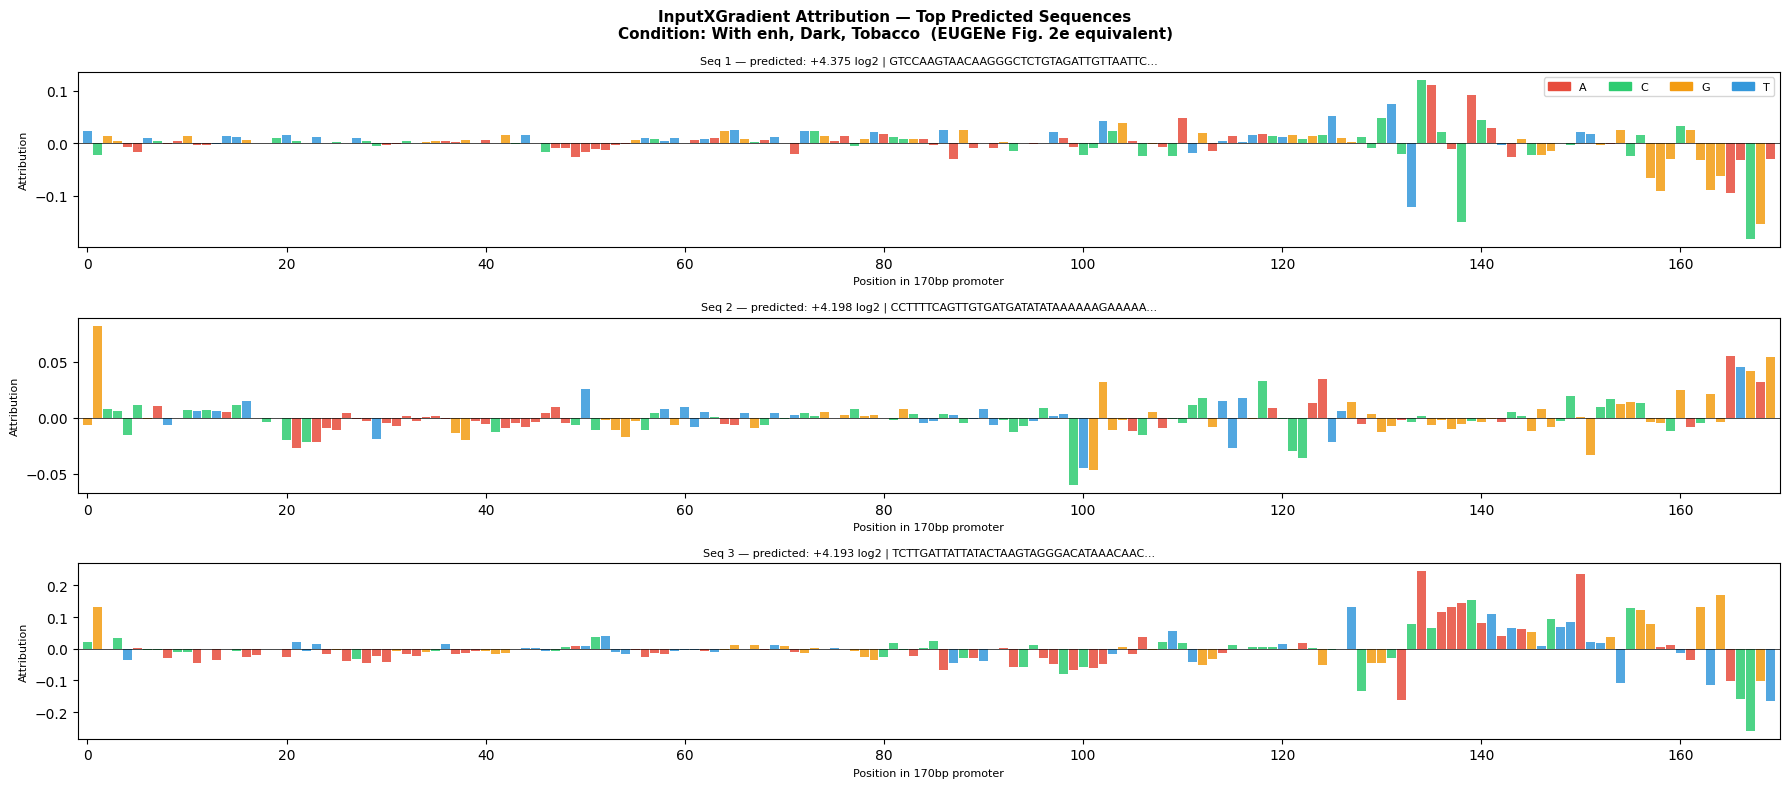

Saved: attribution_top_sequences.png ✓


In [ ]:
# ── Nucleotide Attribution (InputXGradient) ───────────────────────────────────
print("EUGENe Analysis 3/5 — Nucleotide Attribution (Fig. 2e)")
print("="*60)
print("InputXGradient: which nucleotides at which positions drive predictions?")
print("Positive = increases activity. Negative = suppresses activity.\n")

cond_idx_a = 2   # With enh, Dark, Tobacco
model_attr = trained_models[COND_COLS[cond_idx_a]]
model_attr.eval()

# ── Find top 5 highest-predicted test sequences ───────────────────────────────
print("Finding top 5 highest-predicted test sequences...")
all_preds_a = []
with torch.no_grad():
    for oh, lm, gc, sp, lab in datasets[COND_COLS[cond_idx_a]]["test"]:
        p = model_attr(oh.to(DEVICE), lm.to(DEVICE), gc.to(DEVICE), sp.to(DEVICE))
        all_preds_a.extend(p.cpu().numpy())

top5      = np.argsort(all_preds_a)[-5:][::-1]
top5_seqs = [datasets[COND_COLS[cond_idx_a]]["test_seqs"][i] for i in top5]
top5_gc   = [datasets[COND_COLS[cond_idx_a]]["test_gc"][i]   for i in top5]
top5_sp   = [encode_species(datasets[COND_COLS[cond_idx_a]]["test_sp"][i]) for i in top5]
top5_pred = [all_preds_a[i] for i in top5]
print(f"Top predicted scores: {[round(p,3) for p in top5_pred]}")

def compute_attribution(seq, gc_v, sp_v, model):
    oh_np = one_hot_encode(seq)
    oh_t  = torch.tensor(oh_np).unsqueeze(0).to(DEVICE).requires_grad_(True)
    emb   = get_embedding(seq)
    gc_t  = torch.tensor([[gc_v]], dtype=torch.float32).to(DEVICE)
    sp_t  = torch.tensor(sp_v).unsqueeze(0).to(DEVICE)

    # BiLSTM requires train() mode for backward pass
    # Dropout disabled by setting to eval first, then train with no_dropout trick
    model.train()                        # ← switches RNN to allow backward
    model.zero_grad()
    with torch.backends.cudnn.flags(enabled=False):   # ← disables cuDNN RNN
        out = model(oh_t, emb.detach(), gc_t, sp_t)
    out.backward()
    model.eval()                         # ← switch back immediately

    grad = oh_t.grad.detach().cpu().numpy()[0]
    return grad * oh_np

print("Computing attributions...")
attrs = []
for seq, gc_v, sp_v in zip(top5_seqs, top5_gc, top5_sp):
    a = compute_attribution(seq, gc_v, sp_v, model_attr)
    attrs.append(a)
    print(f"  Done: {seq[:25]}...")

# ── Plot top 3 as sequence logos ──────────────────────────────────────────────
NT_ORDER = ["A","C","G","T"]
NT_CLR   = {"A":"#e74c3c","C":"#2ecc71","G":"#f39c12","T":"#3498db"}

fig, axes = plt.subplots(3, 1, figsize=(18, 8))
fig.suptitle(f"InputXGradient Attribution — Top Predicted Sequences\n"
             f"Condition: {COND_LABELS[cond_idx_a]}  (EUGENe Fig. 2e equivalent)",
             fontsize=11, fontweight="bold")
for ai, ax in enumerate(axes):
    araw = attrs[ai]   # (4, 170)
    pred = top5_pred[ai]
    for pos in range(SEQ_LEN):
        bp_pos, bn_pos = 0.0, 0.0
        for ni, nt in enumerate(NT_ORDER):
            v = float(araw[ni, pos])
            if v >  1e-6:
                ax.bar(pos, v,  bottom=bp_pos, color=NT_CLR[nt], width=0.9, edgecolor="none", alpha=0.85)
                bp_pos += v
            elif v < -1e-6:
                ax.bar(pos, v, bottom=bn_pos, color=NT_CLR[nt], width=0.9, edgecolor="none", alpha=0.85)
                bn_pos += v
    ax.axhline(0, color="black", lw=0.5)
    ax.set_title(f"Seq {ai+1} — predicted: {pred:+.3f} log2 | {top5_seqs[ai][:35]}...",
                 fontsize=8)
    ax.set_xlabel("Position in 170bp promoter", fontsize=8)
    ax.set_ylabel("Attribution", fontsize=8)
    ax.set_xlim(-1, SEQ_LEN)

handles = [plt.Rectangle((0,0),1,1, color=c, label=n) for n,c in NT_CLR.items()]
axes[0].legend(handles=handles, fontsize=8, loc="upper right", ncol=4)
plt.tight_layout()
plt.savefig("attribution_top_sequences.png", dpi=150, bbox_inches="tight"); plt.show()
print("Saved: attribution_top_sequences.png ✓")

## Cell 12f — CNN Filter Motif Visualization + JASPAR Matching (EUGENe Fig. 2c,d)

> Extract maximally activating subsequences per CNN filter → build PFM logos.
> Match against JASPAR CORE Plants. EUGENe found TATA, TCP, ERF filters.
> Also fetches JASPAR profiles for use in Cell 12g (enrichment).

EUGENe Analysis 4/5 — CNN Filter Motif Visualization (Fig. 2c,d)
Step 1: Extract what each CNN filter learned from the data
Step 2: Match those learned motifs against JASPAR plant TFs

First Conv1d: 128 filters × 8bp
Building PFMs for top 20 filters from 300 test sequences...
PFMs built ✓

Fetching JASPAR CORE Plants profiles (500)...
  500 profiles indexed ✓
  500 matrices ready ✓

Filters with significant JASPAR match (r>0.5): 14/20
  Filter  46  AATTATTT  →  AHL12 (MA0932.1) r=0.830
  Filter  80  CAGCCGCC  →  ERF4 (MA0992.1) r=0.734
  Filter  35  GTAACATT  →  EDF3 (MA2459.1) r=0.667
  Filter  36  CGGTGTGG  →  EmBP-1 (MA0128.1) r=0.658
  Filter 125  AAGGACTG  →  ATHB-12 (MA0950.1) r=0.649
  Filter  12  ACACGATT  →  ATHB-15 (MA1026.1) r=0.638
  Filter  19  GCGTGTGG  →  BHLH34 (MA0962.1) r=0.637
  Filter  82  TATATGCG  →  ARR11 (MA0946.1) r=0.616
  Filter   9  GACGATTT  →  DREB1B (MA1669.2) r=0.589
  Filter 118  GCCAGGCC  →  ERF105 (MA1000.1) r=0.547
  Filter  15  ATCTGCCC  →  ERF15 (M

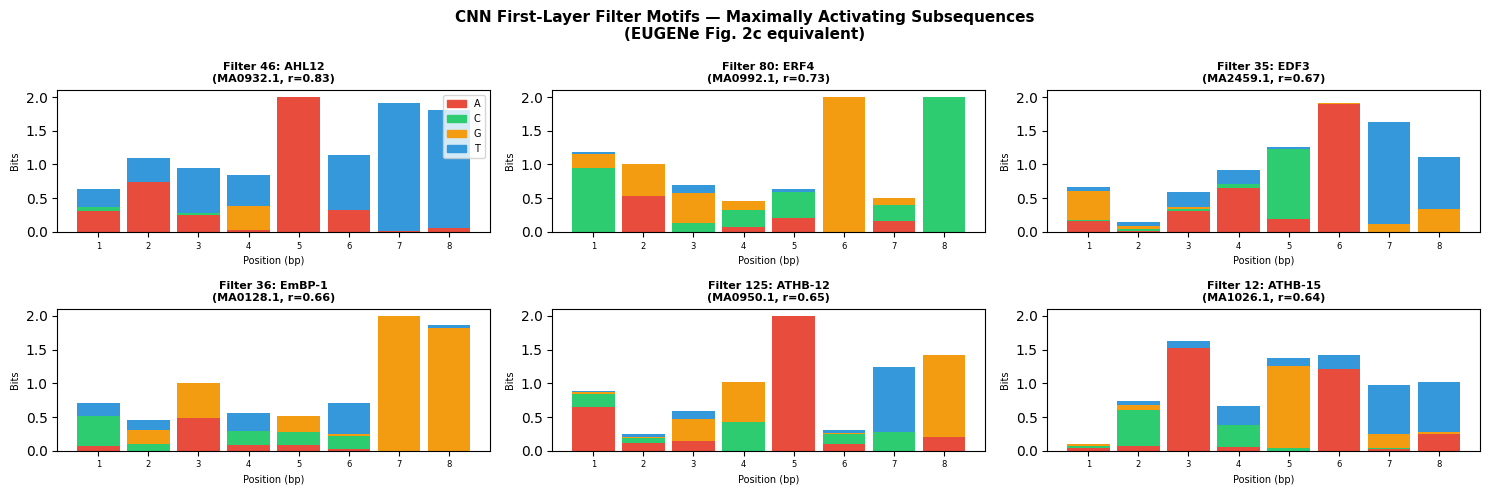

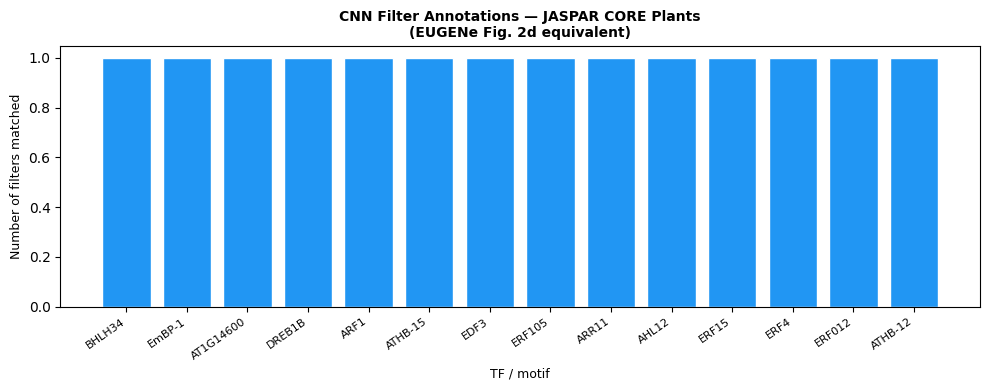

Saved: filter_annotation_histogram.png ✓
Saved: filter_motifs_logo.png ✓

Note: pfm_matrices and pfm_db are now available for Cell 12g (enrichment)


In [ ]:
# ── CNN Filter Motif Visualization + JASPAR ───────────────────────────────────
import requests, time as _time
print("EUGENe Analysis 4/5 — CNN Filter Motif Visualization (Fig. 2c,d)")
print("="*60)
print("Step 1: Extract what each CNN filter learned from the data")
print("Step 2: Match those learned motifs against JASPAR plant TFs\n")

BEST_COND     = COND_COLS[2]   # With enh, Dark, Tobacco
model_fv      = trained_models[BEST_COND]
model_fv.eval()
conv1_weights = model_fv.cnn_branch.cnn[0].weight.data.cpu().numpy()
N_FILT, N_CH, FILT_LEN = conv1_weights.shape
print(f"First Conv1d: {N_FILT} filters × {FILT_LEN}bp")

# ── Step 1: Maximally activating subsequences ─────────────────────────────────
TOP_K     = 100
N_FV_SEQS = 300
fv_seqs   = datasets[BEST_COND]["test_seqs"][:N_FV_SEQS]

def get_max_activating(fi, seqs, weights, top_k=100):
    fw   = weights[fi]
    hits = []
    for seq in seqs:
        oh = one_hot_encode(seq)
        for s in range(SEQ_LEN - FILT_LEN + 1):
            w = oh[:, s:s+FILT_LEN]
            hits.append((float((w * fw).sum()), seq[s:s+FILT_LEN]))
    hits.sort(key=lambda x: -x[0])
    return [sub for _, sub in hits[:top_k]]

def build_pfm(seqs, length):
    NT_IDX = {"A":0,"C":1,"G":2,"T":3}
    pfm = np.zeros((4, length), dtype=np.float32)
    for seq in seqs:
        for j, nt in enumerate(seq.upper()[:length]):
            if nt in NT_IDX: pfm[NT_IDX[nt], j] += 1
    cs = pfm.sum(axis=0, keepdims=True).clip(min=1)
    return pfm / cs

def pfm_bits(pfm):
    eps  = 1e-6
    ic   = 2.0 - (-np.sum(pfm * np.log2(pfm.clip(min=eps)), axis=0))
    return pfm * ic

def consensus(pfm):
    return "".join("ACGT"[pfm[:,j].argmax()] for j in range(pfm.shape[1]))

# Top 20 highest-variance filters (most informative)
filter_var  = conv1_weights.var(axis=(1,2))
top20       = np.argsort(filter_var)[-20:][::-1]
print(f"Building PFMs for top 20 filters from {N_FV_SEQS} test sequences...")

filter_pfms = {}
for fi in top20:
    seqs_fi = get_max_activating(fi, fv_seqs, conv1_weights, TOP_K)
    filter_pfms[fi] = build_pfm(seqs_fi, FILT_LEN)
print("PFMs built ✓")

# ── Step 2: Fetch JASPAR CORE Plants and match ────────────────────────────────
print("\nFetching JASPAR CORE Plants profiles (500)...")
JASPAR_API = "https://jaspar.elixir.no/api/v1"

resp = requests.get(f"{JASPAR_API}/matrix/",
    params={"collection":"CORE","tax_group":"plants","format":"json","page_size":500},
    timeout=30)
plant_profiles = resp.json()["results"]
pfm_db = {p["matrix_id"]: {
    "name":   p["name"],
    "family": p.get("family",["Unknown"])[0] if p.get("family") else "Unknown"
} for p in plant_profiles}
print(f"  {len(pfm_db)} profiles indexed ✓")

print("  Downloading PFM matrices (this takes ~2 min)...")
pfm_matrices = {}
for mid in list(pfm_db.keys()):
    r = requests.get(f"{JASPAR_API}/matrix/{mid}/", timeout=15)
    if r.status_code != 200: continue
    d = r.json(); pfm = d.get("pfm",{})
    if not pfm or not pfm.get("A"): continue
    mat = np.array([pfm["A"],pfm["C"],pfm["G"],pfm["T"]], dtype=np.float32)
    cs  = mat.sum(axis=0, keepdims=True); cs[cs==0]=1
    pfm_matrices[mid] = mat/cs
    _time.sleep(0.04)
print(f"  {len(pfm_matrices)} matrices ready ✓")

# Match each filter PFM to best JASPAR motif (Pearson correlation)
def pfm_corr(q, d):
    if q.shape[1] != d.shape[1]: return 0.0
    qf = q.flatten(); df = d.flatten()
    if qf.std() < 1e-6 or df.std() < 1e-6: return 0.0
    return float(np.corrcoef(qf, df)[0,1])

filter_ann = {}
for fi, f_pfm in filter_pfms.items():
    best_r, best_mid = -1, None
    for mid, db_pfm in pfm_matrices.items():
        r = pfm_corr(f_pfm, db_pfm)
        if r > best_r: best_r, best_mid = r, mid
    if best_mid and best_r > 0.5:
        filter_ann[fi] = {"jaspar_id":best_mid, "tf_name":pfm_db[best_mid]["name"],
                          "corr":round(best_r,3)}

print(f"\nFilters with significant JASPAR match (r>0.5): {len(filter_ann)}/{len(top20)}")
for fi, ann in sorted(filter_ann.items(), key=lambda x: -x[1]["corr"]):
    print(f"  Filter {fi:3d}  {consensus(filter_pfms[fi])}  →  "
          f"{ann['tf_name']} ({ann['jaspar_id']}) r={ann['corr']:.3f}")

# ── Plot: top 6 filter logos ──────────────────────────────────────────────────
to_show = sorted(filter_ann.items(), key=lambda x: -x[1]["corr"])[:6]
if len(to_show) < 6:   # pad with top-var unannotated filters
    for fi in top20:
        if fi not in [x[0] for x in to_show]:
            to_show.append((fi, {"tf_name":consensus(filter_pfms[fi]),
                                  "jaspar_id":"—","corr":0}))
        if len(to_show) >= 6: break

CLR_NT = {"A":"#e74c3c","C":"#2ecc71","G":"#f39c12","T":"#3498db"}
fig, axes = plt.subplots(2, 3, figsize=(15, 5))
axes = axes.flatten()
fig.suptitle("CNN First-Layer Filter Motifs — Maximally Activating Subsequences\n"
             "(EUGENe Fig. 2c equivalent)", fontsize=11, fontweight="bold")
for ax, (fi, ann) in zip(axes, to_show[:6]):
    bits = pfm_bits(filter_pfms[fi])
    bots = np.zeros(FILT_LEN)
    for ni, (nt, c) in enumerate(CLR_NT.items()):
        ax.bar(range(FILT_LEN), bits[ni], bottom=bots, color=c, width=0.85, edgecolor="none")
        bots += bits[ni]
    ttl = f"Filter {fi}: {ann['tf_name']}"
    if ann['jaspar_id'] != "—": ttl += f"\n({ann['jaspar_id']}, r={ann['corr']:.2f})"
    ax.set_title(ttl, fontsize=8, fontweight="bold")
    ax.set_xlabel("Position (bp)", fontsize=7)
    ax.set_ylabel("Bits", fontsize=7)
    ax.set_ylim(0, 2.1); ax.set_xticks(range(FILT_LEN))
    ax.set_xticklabels(range(1, FILT_LEN+1), fontsize=6)
handles = [plt.Rectangle((0,0),1,1,color=c) for c in CLR_NT.values()]
axes[0].legend(handles, CLR_NT.keys(), fontsize=7, loc="upper right")
plt.tight_layout()
plt.savefig("filter_motifs_logo.png", dpi=150, bbox_inches="tight"); plt.show()

# ── Histogram of TF family matches (EUGENe Fig 2d) ───────────────────────────
tf_counts = {}
for ann in filter_ann.values():
    tf_counts[ann["tf_name"]] = tf_counts.get(ann["tf_name"],0) + 1
if tf_counts:
    fig, ax = plt.subplots(figsize=(10,4))
    tfs = sorted(tf_counts, key=lambda x: -tf_counts[x])
    ax.bar(tfs, [tf_counts[t] for t in tfs], color="#2196F3", edgecolor="white")
    ax.set_xlabel("TF / motif", fontsize=9)
    ax.set_ylabel("Number of filters matched", fontsize=9)
    ax.set_title("CNN Filter Annotations — JASPAR CORE Plants\n"
                 "(EUGENe Fig. 2d equivalent)", fontsize=10, fontweight="bold")
    plt.xticks(rotation=35, ha="right", fontsize=8)
    plt.tight_layout()
    plt.savefig("filter_annotation_histogram.png", dpi=150, bbox_inches="tight"); plt.show()
    print("Saved: filter_annotation_histogram.png ✓")

print("Saved: filter_motifs_logo.png ✓")
print("\nNote: pfm_matrices and pfm_db are now available for Cell 12g (enrichment)")

JASPAR Motif Matching — ISM high-importance regions
Scanning each ISM active region against 500 JASPAR plant motifs.
Uses pfm_matrices and pfm_db from Cell 12f.

Scanning 90 active regions × 500 motifs...
  90/90 regions scanned...
Scan complete ✓
  Significant matches (≥60%): 10/90


,Condition,Start_bp,End_bp,Subsequence,ISM_score,TF_Name,TF_Family,JASPAR_ID,Pct_max
0,"With enh, Dark, Tobacco",110,119,CTATATAAAC,0.9472,AHL13,Unknown,MA2374.1,64.1%
2,"No enh, Dark, Tobacco",110,119,CTATATAAAC,0.8501,AHL13,Unknown,MA2374.1,64.1%
4,"With enh, Light, Tobacco",110,119,CTATATAAAC,0.7773,AHL13,Unknown,MA2374.1,64.1%
7,"No enh, Dark, Maize",109,119,TCTATATAAAC,0.7008,AHL13,Unknown,MA2374.1,64.1%
11,"With enh, Dark, Tobacco",64,76,GCTATTTAAAAAT,0.6435,DOF5.7,Unknown,MA0984.2,76.6%
16,"With enh, Dark, Maize",109,120,TCTATATAAACA,0.5798,AHL13,Unknown,MA2374.1,64.1%
21,"No enh, Light, Tobacco",65,76,CTATTTAAAAAT,0.5346,DOF5.7,Unknown,MA0984.2,76.6%
35,"With enh, Light, Tobacco",65,76,CTATTTAAAAAT,0.4259,DOF5.7,Unknown,MA0984.2,76.6%
36,"No enh, Dark, Tobacco",65,77,CTATTTAAAAATG,0.4248,DOF5.7,Unknown,MA0984.2,76.6%
63,"With enh, Dark, Maize",132,169,GTTCCTTAAAACCGCTGCTCTTCAACATCAATTTCGCC,0.2374,ERF069,Unknown,MA0997.2,67.7%



Top matched TF families:
  Unknown                            : 10 region(s)

Saved: jaspar_motif_matches.csv (90 rows, 10 hits)

Plotting ISM profile with JASPAR annotations...


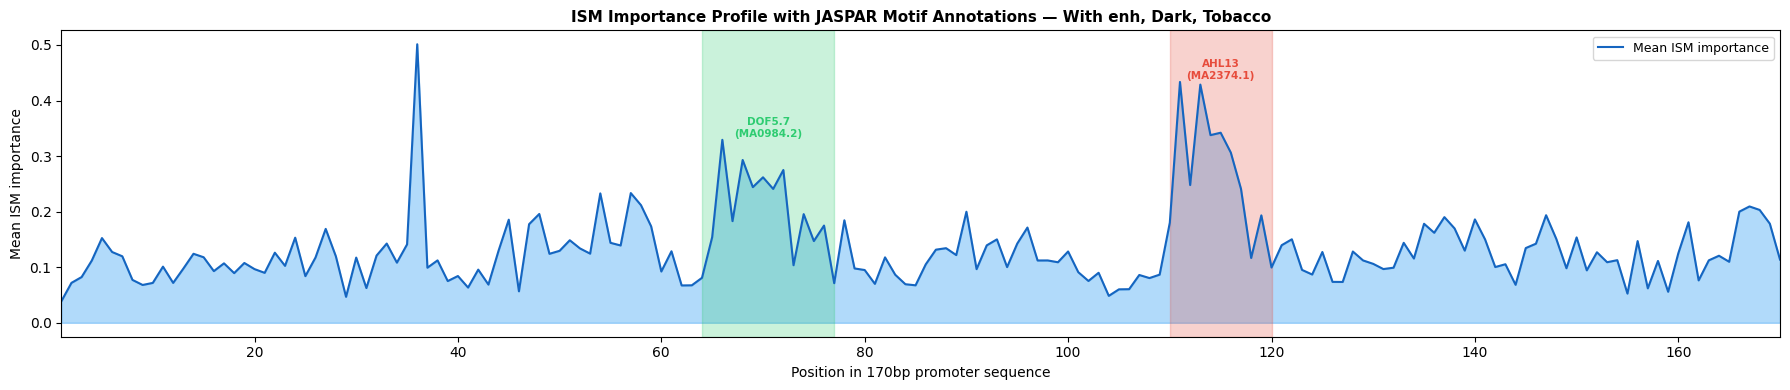

Saved: jaspar_ism_annotated.png ✓


In [ ]:
# ── JASPAR ISM Region Matching (per-region annotation) ───────────────────────
import requests, time as _time
print("JASPAR Motif Matching — ISM high-importance regions")
print("="*60)
print("Scanning each ISM active region against 500 JASPAR plant motifs.")
print("Uses pfm_matrices and pfm_db from Cell 12f.\n")

SCORE_THRESHOLD = 0.60
NT_IDX_J = {"A":0,"C":1,"G":2,"T":3}
bg_j = 0.25

def seq_to_prob(seq):
    mat = np.zeros((4, len(seq)), dtype=np.float32)
    for i, nt in enumerate(seq.upper()):
        if nt in NT_IDX_J: mat[NT_IDX_J[nt], i] = 1.0
    return mat

def score_pfm(seq_mat, pfm_mat):
    L_seq, L_mot = seq_mat.shape[1], pfm_mat.shape[1]
    if L_mot > L_seq: return -999.0, -1
    log_pfm = np.log2(np.clip(pfm_mat, 1e-6, 1) / bg_j)
    best, best_pos = -999.0, 0
    for s in range(L_seq - L_mot + 1):
        sc = float((seq_mat[:, s:s+L_mot] * log_pfm).sum())
        if sc > best: best, best_pos = sc, s
    return best, best_pos

def max_pfm_score(pfm_mat):
    log_pfm = np.log2(np.clip(pfm_mat, 1e-6, 1) / bg_j)
    return float(log_pfm.clip(min=0).sum())

# Scan all ISM active regions
jaspar_rows = []
total = len(summary_df)
print(f"Scanning {total} active regions × {len(pfm_matrices)} motifs...")

for idx, row in summary_df.iterrows():
    subseq  = row["Subsequence"].upper()
    seq_mat = seq_to_prob(subseq)
    best_hit = {"matrix_id":None,"name":"No significant match",
                "family":"—","score":0.0,"pct_max":0.0,"pos":-1}

    for mid, pfm_mat in pfm_matrices.items():
        score, pos = score_pfm(seq_mat, pfm_mat)
        max_s = max_pfm_score(pfm_mat)
        if max_s <= 0: continue
        pct = score / max_s
        if pct > best_hit["pct_max"]:
            best_hit = {"matrix_id":mid,
                        "name":pfm_db[mid]["name"],
                        "family":pfm_db[mid]["family"],
                        "score":round(score,3),
                        "pct_max":round(pct,3),"pos":pos}

    jaspar_rows.append({
        "Condition":   row["Condition"],
        "Start_bp":    row["Start"],
        "End_bp":      row["End"],
        "Subsequence": subseq,
        "ISM_score":   row["Importance"],
        "JASPAR_ID":   best_hit["matrix_id"] if best_hit["pct_max"] >= SCORE_THRESHOLD else "—",
        "TF_Name":     best_hit["name"]      if best_hit["pct_max"] >= SCORE_THRESHOLD else "No significant match",
        "TF_Family":   best_hit["family"]    if best_hit["pct_max"] >= SCORE_THRESHOLD else "—",
        "Match_score": best_hit["score"]     if best_hit["pct_max"] >= SCORE_THRESHOLD else 0.0,
        "Pct_max":     best_hit["pct_max"]   if best_hit["pct_max"] >= SCORE_THRESHOLD else 0.0,
    })
    if (idx+1) % 10 == 0:
        print(f"  {idx+1}/{total} regions scanned...", end="\r")

print(f"\nScan complete ✓")
jaspar_df = pd.DataFrame(jaspar_rows)
n_hits    = (jaspar_df["JASPAR_ID"] != "—").sum()
print(f"  Significant matches (≥{SCORE_THRESHOLD*100:.0f}%): {n_hits}/{total}")

top_hits = jaspar_df[jaspar_df["JASPAR_ID"] != "—"].sort_values(
    "ISM_score", ascending=False)
display(top_hits[["Condition","Start_bp","End_bp","Subsequence",
                  "ISM_score","TF_Name","TF_Family","JASPAR_ID","Pct_max"]]
        .style
        .background_gradient(subset=["ISM_score","Pct_max"], cmap="YlOrRd")
        .format({"ISM_score":"{:.4f}","Pct_max":"{:.1%}"})
        .set_caption("ISM high-importance regions matched to JASPAR CORE Plants"))

print("\nTop matched TF families:")
for fam, cnt in top_hits["TF_Family"].value_counts().items():
    print(f"  {fam:<35}: {cnt} region(s)")

jaspar_df.to_csv("jaspar_motif_matches.csv", index=False)
print(f"\nSaved: jaspar_motif_matches.csv ({len(jaspar_df)} rows, {n_hits} hits)")

# ── Annotated ISM plot ────────────────────────────────────────────────────────
print("\nPlotting ISM profile with JASPAR annotations...")
fig, ax = plt.subplots(figsize=(18, 4))
cond_idx_j = 2
mean_imp = np.stack([r["importance"][:,cond_idx_j]
                     for r in ism_results]).mean(axis=0)
ax.fill_between(range(1,SEQ_LEN+1), mean_imp, alpha=0.35, color="#2196F3")
ax.plot(range(1,SEQ_LEN+1), mean_imp, color="#1565C0", lw=1.5,
        label="Mean ISM importance")

ANNOT_COLORS = ["#e74c3c","#2ecc71","#9b59b6","#f39c12","#1abc9c"]
hits_cond = top_hits[top_hits["Condition"] == COND_LABELS[cond_idx_j]]
for ai, (_, hit) in enumerate(hits_cond.iterrows()):
    s, e   = int(hit["Start_bp"])-1, int(hit["End_bp"])
    color  = ANNOT_COLORS[ai % len(ANNOT_COLORS)]
    ax.axvspan(s+1, e+1, alpha=0.25, color=color)
    ax.text((s+e)/2+1, mean_imp[s:e].max()+0.002,
            f"{hit['TF_Name']}\n({hit['JASPAR_ID']})",
            ha="center", va="bottom", fontsize=7.5,
            color=color, fontweight="bold")

ax.set_xlabel("Position in 170bp promoter sequence", fontsize=10)
ax.set_ylabel("Mean ISM importance", fontsize=10)
ax.set_title(f"ISM Importance Profile with JASPAR Motif Annotations — "
             f"{COND_LABELS[cond_idx_j]}", fontsize=11, fontweight="bold")
ax.set_xlim(1, SEQ_LEN); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("jaspar_ism_annotated.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: jaspar_ism_annotated.png ✓")

## Cell 12g — JASPAR Motif Enrichment Analysis (Statistical)

> Are the TF motifs found in high-importance ISM regions statistically enriched
> vs low-importance background? Uses Fisher's exact test + Bonferroni correction.
> Turns 13 individual hits into a statistically validated finding.
>
> **Requires Cell 12c (ISM) and Cell 12f (JASPAR fetch) to have run first.**

In [ ]:
# ── JASPAR Enrichment Analysis ────────────────────────────────────────────────
from scipy.stats import fisher_exact
print("EUGENe Analysis 5/5 — JASPAR Motif Enrichment Analysis")
print("="*60)
print("Are TF motifs enriched in HIGH-importance regions vs background?")
print("Fisher's exact test + Bonferroni correction.\n")

# Uses summary_df (from Cell 12) and pfm_matrices/pfm_db (from Cell 12f)
ENRICH_THRESH = 0.60

# Split ISM regions into high (above median) and background (below median)
med_imp = summary_df["Importance"].median()
high_seqs = summary_df[summary_df["Importance"] >= med_imp]["Subsequence"].tolist()
bg_seqs   = summary_df[summary_df["Importance"] <  med_imp]["Subsequence"].tolist()
print(f"High-importance regions : {len(high_seqs)}")
print(f"Background regions      : {len(bg_seqs)}")

NT_IDX_E = {"A":0,"C":1,"G":2,"T":3}
bg_e = 0.25

def seq_to_mat(seq):
    mat = np.zeros((4, len(seq)), dtype=np.float32)
    for i, nt in enumerate(seq.upper()):
        if nt in NT_IDX_E: mat[NT_IDX_E[nt],i] = 1.0
    return mat

def has_motif_hit(seq, pfm_mat, threshold):
    sm = seq_to_mat(seq)
    L_seq, L_mot = sm.shape[1], pfm_mat.shape[1]
    if L_mot > L_seq: return False
    log_pfm = np.log2(np.clip(pfm_mat, 1e-6, 1) / bg_e)
    max_s   = float(log_pfm.clip(min=0).sum())
    if max_s <= 0: return False
    for s in range(L_seq - L_mot + 1):
        if float((sm[:, s:s+L_mot] * log_pfm).sum()) / max_s >= threshold:
            return True
    return False

def count_hits(seqs, pfm_matrices, threshold):
    counts = {}
    for mid, pfm_mat in pfm_matrices.items():
        c = sum(1 for s in seqs if has_motif_hit(s, pfm_mat, threshold))
        if c > 0: counts[mid] = c
    return counts

print("\nCounting motif hits in high-importance regions...")
high_hits = count_hits(high_seqs, pfm_matrices, ENRICH_THRESH)
print(f"  Done: {len(high_hits)} motifs have hits.")
print("Counting motif hits in background regions...")
bg_hits   = count_hits(bg_seqs,   pfm_matrices, ENRICH_THRESH)
print(f"  Done: {len(bg_hits)} motifs have hits.")

n_high = len(high_seqs)
n_bg   = len(bg_seqs)
results_enrich = []
for mid in set(list(high_hits.keys()) + list(bg_hits.keys())):
    a = high_hits.get(mid, 0); b = n_high - a
    c = bg_hits.get(mid,   0); d = n_bg   - c
    if a + c == 0: continue
    odds, pval = fisher_exact([[a,b],[c,d]], alternative="greater")
    results_enrich.append({
        "JASPAR_ID": mid, "TF_Name": pfm_db[mid]["name"],
        "High_hits": a, "BG_hits": c,
        "Odds_ratio": round(odds,3), "P_value": pval
    })

enrich_df = pd.DataFrame(results_enrich).sort_values("P_value")
if len(enrich_df) > 0:
    enrich_df["P_adj"] = (enrich_df["P_value"] * len(enrich_df)).clip(upper=1.0).round(4)
    enrich_df["Significant"] = enrich_df["P_adj"] < 0.05
    sig = enrich_df[enrich_df["Significant"]]
    print(f"\nSignificantly enriched TF motifs (Bonferroni p < 0.05): {len(sig)}")
    if len(sig) > 0:
        display(sig[["TF_Name","JASPAR_ID","High_hits","BG_hits","Odds_ratio","P_adj"]]
                .style
                .background_gradient(subset=["Odds_ratio"], cmap="Reds")
                .format({"Odds_ratio":"{:.2f}","P_adj":"{:.4f}"})
                .set_caption("Enriched TF motifs in ISM high-importance regions"))
    else:
        print("  No significant enrichment at p<0.05 — showing top 5 by p-value:")
        display(enrich_df.head(5)[["TF_Name","JASPAR_ID","High_hits","BG_hits",
                                    "Odds_ratio","P_adj"]])
    enrich_df.to_csv("jaspar_enrichment.csv", index=False)
    print("Saved: jaspar_enrichment.csv ✓")

EUGENe Analysis 5/5 — JASPAR Motif Enrichment Analysis
Are TF motifs enriched in HIGH-importance regions vs background?
Fisher's exact test + Bonferroni correction.

High-importance regions : 45
Background regions      : 45

Counting motif hits in high-importance regions...
  Done: 3 motifs have hits.
Counting motif hits in background regions...
  Done: 1 motifs have hits.

Significantly enriched TF motifs (Bonferroni p < 0.05): 1


,TF_Name,JASPAR_ID,High_hits,BG_hits,Odds_ratio,P_adj
2,AHL13,MA2374.1,9,0,inf,0.0050


Saved: jaspar_enrichment.csv ✓


## Cell 13 — Table 6 validation: CPE & TFBS

> **Bug fixed:** CNN branch now receives proper one-hot encodings (was all-zeros before). GC + species also passed.

Loading Table 6 (synthetic promoters)...
Loaded: 2,956 synthetic promoters  CPE types: 8  TFBS combos: 189

TATA-box: 2,892  Inr: 66  Y patch: 64
Has TFBS: 2,829

Predicting activity for all Table 6 sequences (~3-4 min)...

Predictions shape: (2956, 6) ✓



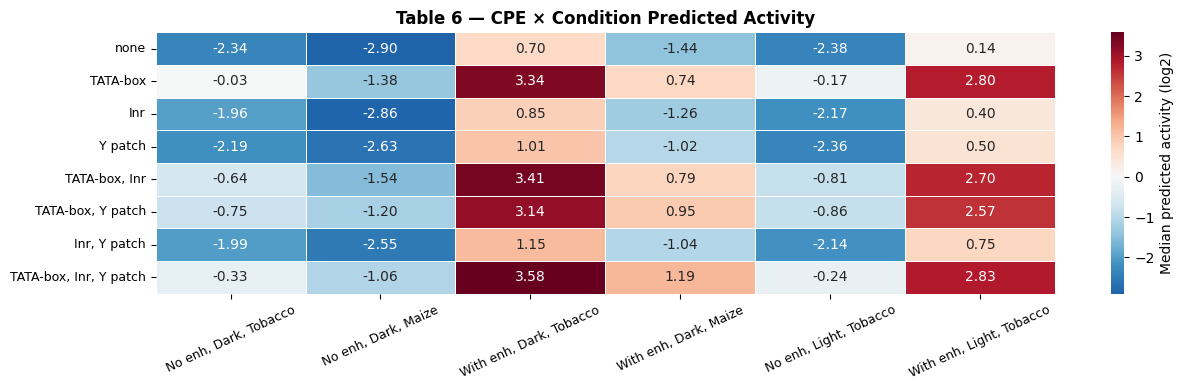

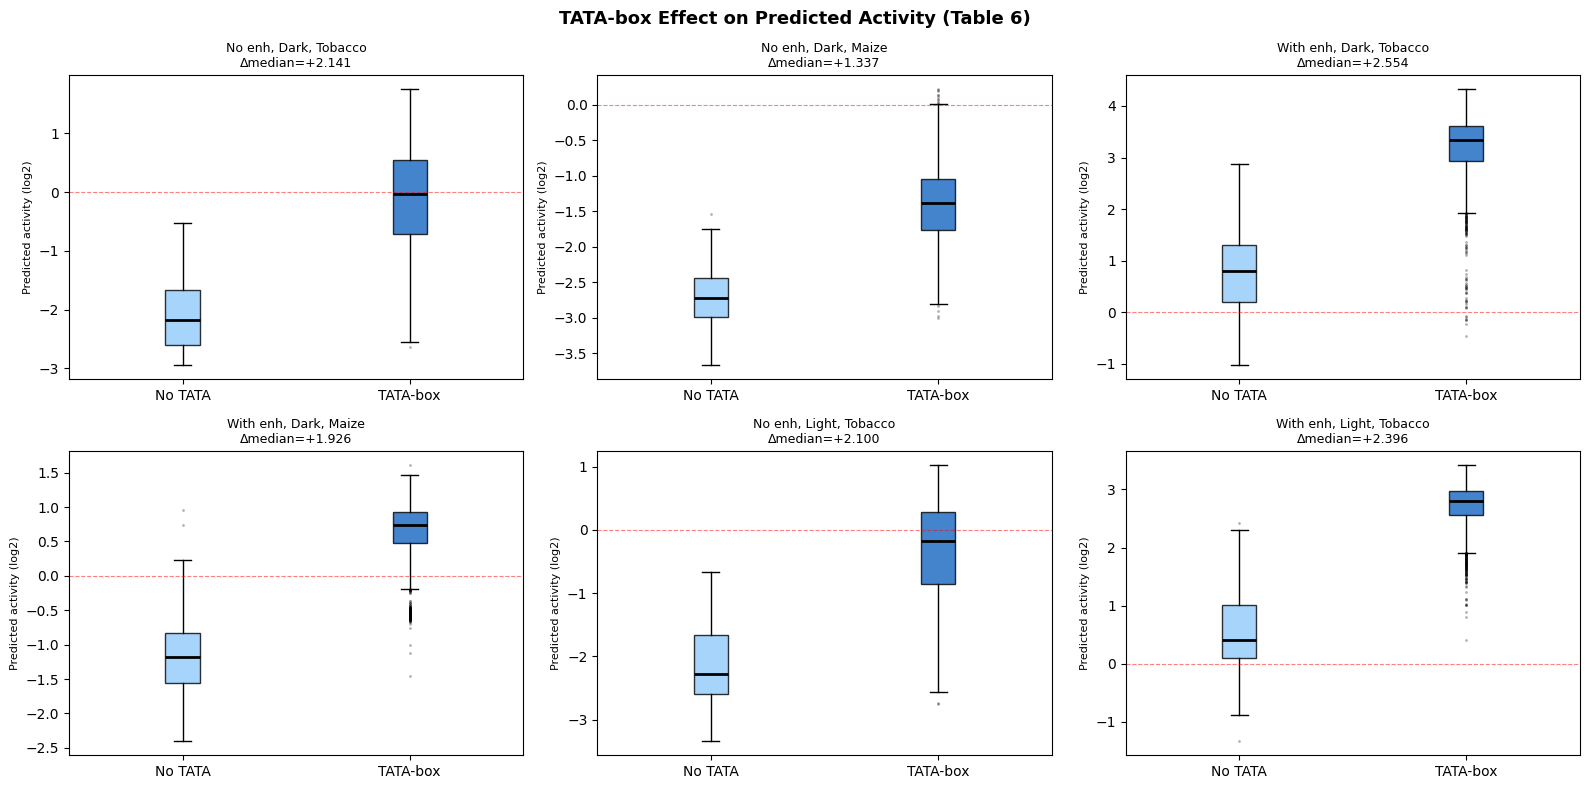

Saved: table6_predictions.csv (2956 rows)

Table 6 Validation Complete ✓


In [ ]:
print("Loading Table 6 (synthetic promoters)...")
df6 = pd.read_excel(XLSX_PATH, sheet_name="Supplementary Table 6", skiprows=3)
df6.columns = df6.columns.str.strip()
df6 = df6[df6["sequence"].astype(str).str.len()==170].copy().reset_index(drop=True)
print(f"Loaded: {len(df6):,} synthetic promoters  CPE types: {df6['CPEs'].nunique()}  TFBS combos: {df6['TFBSs'].nunique()}\n")

CPE_TYPES = ["TATA-box","Inr","Y patch"]
def parse_cpes(s):
    if pd.isna(s) or str(s).strip().lower()=="none": return {c:0 for c in CPE_TYPES}
    return {c:int(c in str(s)) for c in CPE_TYPES}
def parse_tfbs(s):
    if pd.isna(s) or str(s).strip().lower()=="none": return []
    res = []
    for part in str(s).split(","):
        part = part.strip()
        if "(" in part and ")" in part:
            res.append((part[:part.index("(")].strip(), int(part[part.index("(")+1:part.index(")")])))
    return res

cpe_df = pd.DataFrame([parse_cpes(v) for v in df6["CPEs"]])
df6    = pd.concat([df6.reset_index(drop=True), cpe_df], axis=1)
df6["n_tfbs"]  = df6["TFBSs"].apply(lambda x: len(parse_tfbs(x)))
df6["has_TATA"]= df6["TATA-box"].astype(bool)
print(f"TATA-box: {df6['has_TATA'].sum():,}  Inr: {df6['Inr'].sum():,}  Y patch: {df6['Y patch'].sum():,}")
print(f"Has TFBS: {(df6['n_tfbs']>0).sum():,}\n")

# ── Predict Table 6 — FIXED: proper one-hot + GC + species ───────────────────
print("Predicting activity for all Table 6 sequences (~3-4 min)...")

@torch.no_grad()
def predict_table6(sequences, batch_size=32):
    # Pre-compute LM embeddings in batches
    all_tokens = []
    for seq in sequences:
        tok = tokenize_sequence(seq)
        all_tokens.append({"input_ids": tok["input_ids"].squeeze(0),
                            "attention_mask": tok["attention_mask"].squeeze(0)})
    PAD_ID_T6 = tokenizer.pad_token_id if hasattr(tokenizer,"pad_token_id") and tokenizer.pad_token_id is not None else 0
    lm_embs_list = []; n = len(all_tokens)
    for i in range(0, n, batch_size):
        batch    = all_tokens[i:i+batch_size]
        max_len  = max(t["input_ids"].shape[0] for t in batch)
        ids_list, mask_list = [], []
        for t in batch:
            ids  = t["input_ids"]; mask = t["attention_mask"]; pad = max_len - ids.shape[0]
            ids_list.append( torch.nn.functional.pad(ids,  (0,pad), value=PAD_ID_T6))
            mask_list.append(torch.nn.functional.pad(mask, (0,pad), value=0))
        input_ids = torch.stack(ids_list).to(DEVICE)
        attn_mask = torch.stack(mask_list).to(DEVICE)
        with torch.cuda.amp.autocast():
            out = agro_encoder(input_ids=input_ids, attention_mask=attn_mask)
        hidden = out.last_hidden_state.float()
        mask_f = attn_mask.unsqueeze(-1).float()
        pooled = (hidden * mask_f).sum(1) / mask_f.sum(1)
        lm_embs_list.append(pooled.cpu())
        done = min(i+batch_size, n)
        if done%500==0 or done==n: print(f"  {done:,}/{n:,}({done/n*100:.0f})%", end="\r")

    lm_embs_all = torch.cat(lm_embs_list, dim=0)  # (N, LM_DIM)

    # Now run hybrid model with CORRECT inputs
    all_preds = []
    for i in range(0, n, batch_size):
        batch_seqs = sequences[i:i+batch_size]
        # ✅ FIX: actually encode each sequence
        oh_batch  = torch.tensor(np.array([one_hot_encode(s) for s in batch_seqs]),
                                 dtype=torch.float32).to(DEVICE)
        lm_batch  = lm_embs_all[i:i+batch_size].to(DEVICE)
        # Table 6 = synthetic Arabidopsis promoters
        gc_batch  = torch.tensor([[compute_gc(s)] for s in batch_seqs],
                                 dtype=torch.float32).to(DEVICE)
        sp_batch  = torch.tensor(np.array([encode_species("Arabidopsis") for _ in batch_seqs]),
                                 dtype=torch.float32).to(DEVICE)
        batch_preds = np.stack([trained_models[c](oh_batch, lm_batch, gc_batch, sp_batch)
                                .cpu().numpy() for c in COND_COLS], axis=1)
        all_preds.append(batch_preds)

    print()
    return np.concatenate(all_preds, axis=0)

t6_preds = predict_table6(df6["sequence"].tolist())
for i, col in enumerate(COND_COLS): df6[f"pred_{i}"] = t6_preds[:,i]
print(f"Predictions shape: {t6_preds.shape} ✓\n")

COLORS_ = ["#2196F3","#FF9800","#4CAF50","#9C27B0","#00BCD4","#F44336"]

# Plot 1: CPE x Condition heatmap
cpe_order = ["none","TATA-box","Inr","Y patch","TATA-box, Inr",
             "TATA-box, Y patch","Inr, Y patch","TATA-box, Inr, Y patch"]
hm_data, hm_idx = [], []
for cpe in cpe_order:
    sub = df6[df6["CPEs"].astype(str)==cpe]
    if len(sub)==0: continue
    hm_data.append([np.median(sub[f"pred_{i}"].values) for i in range(6)]); hm_idx.append(cpe)
hm_df = pd.DataFrame(hm_data, index=hm_idx, columns=COND_LABELS)
fig, ax = plt.subplots(figsize=(13,4))
sns.heatmap(hm_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label":"Median predicted activity (log2)"}, linewidths=0.5)
ax.set_title("Table 6 — CPE × Condition Predicted Activity", fontsize=12, fontweight="bold")
ax.tick_params(axis="x",rotation=25,labelsize=9); ax.tick_params(axis="y",rotation=0,labelsize=9)
plt.tight_layout(); plt.savefig("table6_cpe_heatmap.png",dpi=150,bbox_inches="tight"); plt.show()

# Plot 2: TATA-box effect
fig, axes = plt.subplots(2,3,figsize=(16,8)); axes=axes.flatten()
fig.suptitle("TATA-box Effect on Predicted Activity (Table 6)", fontsize=13, fontweight="bold")
for i,(col,label) in enumerate(zip(COND_COLS,COND_LABELS)):
    ax=axes[i]
    no_t=df6[~df6["has_TATA"]][f"pred_{i}"].values; yes_t=df6[df6["has_TATA"]][f"pred_{i}"].values
    bp=ax.boxplot([no_t,yes_t],patch_artist=True,labels=["No TATA","TATA-box"],
                  medianprops=dict(color="black",linewidth=2),flierprops=dict(marker=".",markersize=2,alpha=0.3))
    bp["boxes"][0].set_facecolor("#90CAF9"); bp["boxes"][0].set_alpha(0.8)
    bp["boxes"][1].set_facecolor("#1565C0"); bp["boxes"][1].set_alpha(0.8)
    delta=np.median(yes_t)-np.median(no_t)
    ax.axhline(0,color="red",ls="--",lw=0.8,alpha=0.5)
    ax.set_title(f"{label}\nΔmedian={delta:+.3f}",fontsize=9)
    ax.set_ylabel("Predicted activity (log2)",fontsize=8)
plt.tight_layout(); plt.savefig("table6_tata_effect.png",dpi=150,bbox_inches="tight"); plt.show()

# Save
t6_sum=pd.DataFrame([{"Promoter":row["promoter"],"CPEs":row["CPEs"],"N_TFBS":row["n_tfbs"],
    "Has_TATA":row["has_TATA"],"Max_pred":round(max([row[f"pred_{i}"] for i in range(6)]),3),
    "Mean_pred":round(np.mean([row[f"pred_{i}"] for i in range(6)]),3),
    **{f"Pred_{COND_LABELS[i][:10]}":round(row[f"pred_{i}"],3) for i in range(6)}}
    for _,row in df6.iterrows()]).sort_values("Max_pred",ascending=False)
t6_sum.to_csv("table6_predictions.csv",index=False)
print(f"Saved: table6_predictions.csv ({len(t6_sum)} rows)")
print("\nTable 6 Validation Complete ✓")

## Cell 13b — Permutation feature importance

> **New:** Shuffle each branch independently and measure R² drop. Answers: 'which branch is doing the work?'

Computing permutation feature importance (test set)...

  No enh, Dark, Tobacco          baseline R²=0.651  drops=[0.808, 0.06, -0.0, 0.186]
  No enh, Dark, Maize            baseline R²=0.600  drops=[0.735, 0.026, 0.0, 0.463]
  With enh, Dark, Tobacco        baseline R²=0.773  drops=[1.263, 0.049, -0.0, 0.057]
  With enh, Dark, Maize          baseline R²=0.754  drops=[1.131, 0.04, 0.0, 0.148]
  No enh, Light, Tobacco         baseline R²=0.621  drops=[0.832, 0.093, -0.0, 0.045]
  With enh, Light, Tobacco       baseline R²=0.752  drops=[1.099, 0.064, -0.0, 0.056]


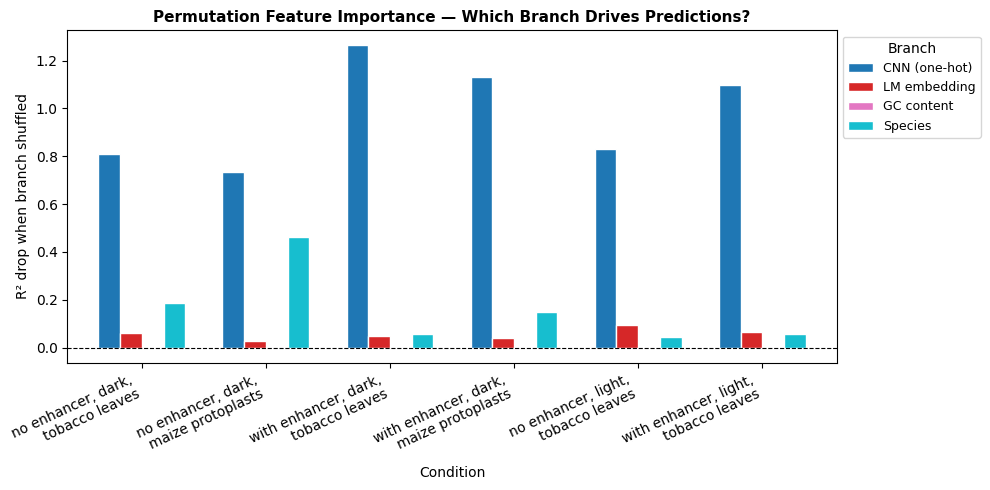


Saved: permutation_importance.png


,CNN (one-hot),LM embedding,GC content,Species
"no enhancer, dark,\ntobacco leaves",0.8081,0.0602,-0.0,0.1856
"no enhancer, dark,\nmaize protoplasts",0.7351,0.0257,0.0,0.4631
"with enhancer, dark,\ntobacco leaves",1.2630,0.0488,-0.0,0.0571
"with enhancer, dark,\nmaize protoplasts",1.1307,0.0397,0.0,0.1480
"no enhancer, light,\ntobacco leaves",0.8320,0.0931,-0.0,0.0455
"with enhancer, light,\ntobacco leaves",1.0995,0.0640,-0.0,0.0561


In [ ]:
# ── Permutation Feature Importance ───────────────────────────────────────────
print("Computing permutation feature importance (test set)...\n")

BRANCHES = {
    "CNN (one-hot)":  "oh",
    "LM embedding":   "lm",
    "GC content":     "gc",
    "Species":        "sp",
}
N_REPEATS  = 5
PERM_BATCH = 256  # batched inference to avoid OOM

def batched_predict(model, OHs, LMs, GCs, SPs, batch_size=PERM_BATCH):
    # runs in chunks — keeps peak VRAM low
    all_preds = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(OHs), batch_size):
            pred = model(OHs[i:i+batch_size].to(DEVICE),
                         LMs[i:i+batch_size].to(DEVICE),
                         GCs[i:i+batch_size].to(DEVICE),
                         SPs[i:i+batch_size].to(DEVICE))
            all_preds.append(pred.cpu().numpy())
    return np.concatenate(all_preds)

perm_results = {col: {} for col in COND_COLS}

for col, label in zip(COND_COLS, COND_LABELS):
    model = trained_models[col]
    # collect test set — stays on CPU until batched_predict moves slices to GPU
    OHs, LMs, GCs, SPs, LABs = [], [], [], [], []
    for oh, lm, gc, sp, lab in datasets[col]["test"]:
        OHs.append(oh); LMs.append(lm); GCs.append(gc)
        SPs.append(sp); LABs.append(lab)
    OHs  = torch.cat(OHs);  LMs  = torch.cat(LMs)
    GCs  = torch.cat(GCs);  SPs  = torch.cat(SPs)
    LABs = torch.cat(LABs).numpy()

    base_r2 = r2_score(LABs, batched_predict(model, OHs, LMs, GCs, SPs))

    all_tensors = {"oh": OHs, "lm": LMs, "gc": GCs, "sp": SPs}
    for bname, bkey in BRANCHES.items():
        drops = []
        for _ in range(N_REPEATS):
            shuffled       = {k: v.clone() for k, v in all_tensors.items()}
            shuffled[bkey] = all_tensors[bkey][torch.randperm(len(OHs))]
            perm_r2        = r2_score(LABs, batched_predict(model, shuffled["oh"],
                                      shuffled["lm"], shuffled["gc"], shuffled["sp"]))
            drops.append(base_r2 - perm_r2)
        perm_results[col][bname] = float(np.mean(drops))
    print(f"  {label:<30} baseline R²={base_r2:.3f}  "
          f"drops={[round(v,3) for v in perm_results[col].values()]}")

perm_df = pd.DataFrame(perm_results, index=BRANCHES.keys()).T
fig, ax = plt.subplots(figsize=(10, 5))
perm_df.plot(kind="bar", ax=ax, colormap="tab10", edgecolor="white", width=0.7)
ax.set_xlabel("Condition", fontsize=10)
ax.set_ylabel("R² drop when branch shuffled", fontsize=10)
ax.set_title("Permutation Feature Importance — Which Branch Drives Predictions?",
             fontsize=11, fontweight="bold")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.legend(title="Branch", fontsize=9, bbox_to_anchor=(1, 1))
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("permutation_importance.png", dpi=150, bbox_inches="tight"); plt.show()
print("\nSaved: permutation_importance.png")
display(perm_df.round(4))

## Cell 14 — Custom sequence prediction

Sequence : GAATATAACGAAAGTAGTACTTAATTTGTT...
GC content: 0.200  Species: Arabidopsis

Condition                       Predicted (log2)
----------------------------------------------------
No enh, Dark, Tobacco           -1.432  ████
No enh, Dark, Maize             -3.402  ██████████
With enh, Dark, Tobacco         + 0.484  █
With enh, Dark, Maize           -2.036  ██████
No enh, Light, Tobacco          -1.740  █████
With enh, Light, Tobacco        + 0.267  

Running ISM on custom sequence...


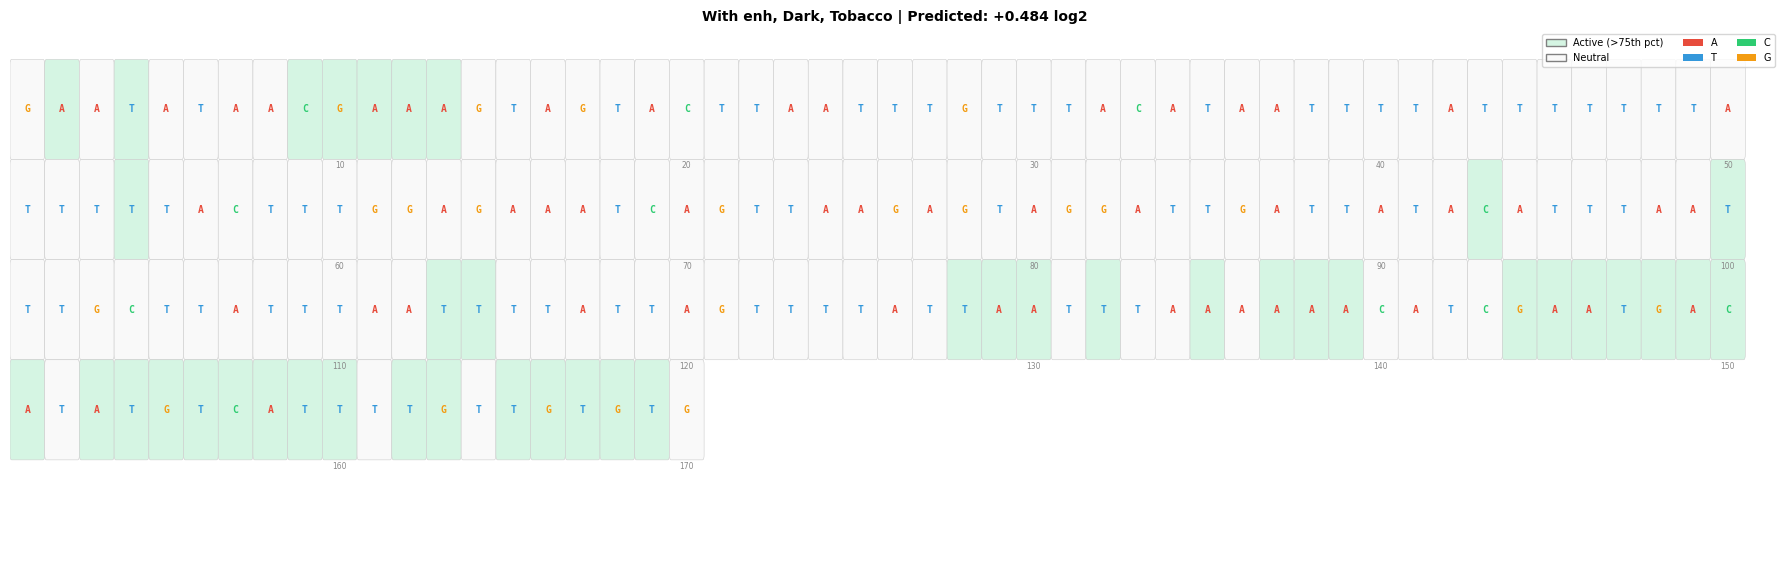


Top active regions (with enhancer, dark, tobacco):
  bp 144-151  GAATGACA              importance=0.2860
  bp 135-135  A                     importance=0.2794
  bp 137-139  AAA                   importance=0.2470


In [ ]:
# PASTE ANY 170bp SEQUENCE HERE ──────────────────────────────────────────────
CUSTOM_SEQ = (
    "GAATATAACGAAAGTAGTACTTAATTTGTTTACATAATTTTATTTTTTTATTTTTACTTT"
    "GGAGAAATCAGTTAAGAGTAGGATTGATTATACATTTAATTTGCTTATTTAATTTTATTAGTTTT"
    "ATTAATTTAAAAAACATCGAATGACATATGTCATTTTGTTGTGTG"
)
CUSTOM_SEQ     = CUSTOM_SEQ.upper().replace(" ","")
CUSTOM_SPECIES = "Arabidopsis"   # change if needed
# ─────────────────────────────────────────────────────────────────────────────

if len(CUSTOM_SEQ) != SEQ_LEN:
    print(f"Sequence is {len(CUSTOM_SEQ)}bp — must be exactly {SEQ_LEN}bp.")
else:
    emb     = get_embedding(CUSTOM_SEQ)
    gc_v    = compute_gc(CUSTOM_SEQ)
    sp_v    = encode_species(CUSTOM_SPECIES)
    oh_t    = torch.tensor(one_hot_encode(CUSTOM_SEQ)).unsqueeze(0).to(DEVICE)
    gc_t    = torch.tensor([[gc_v]], dtype=torch.float32).to(DEVICE)
    sp_t    = torch.tensor(sp_v).unsqueeze(0).to(DEVICE)

    print(f"Sequence : {CUSTOM_SEQ[:30]}...")
    print(f"GC content: {gc_v:.3f}  Species: {CUSTOM_SPECIES}")
    print(f"\n{'Condition':<30}  {'Predicted (log2)':>16}")
    print("-"*52)
    for col, label in zip(COND_COLS, COND_LABELS):
        v = trained_models[col](oh_t, emb, gc_t, sp_t).item()
        bar = "█" * max(0, int(abs(v)*3)); sign = "+" if v >= 0 else ""
        print(f"{label:<30}  {sign}{v:>6.3f}  {bar}")

    print("\nRunning ISM on custom sequence...")
    imp, preds = compute_ism(CUSTOM_SEQ, COND_COLS, gc_v, sp_v)
    custom_res = {"sequence":CUSTOM_SEQ,"importance":imp,"predictions":preds}
    plot_seq_view(custom_res, cond_idx=2)
    print("\nTop active regions (with enhancer, dark, tobacco):")
    for start, end, score in find_active_regions(imp[:,2]):
        subseq = CUSTOM_SEQ[start:end+1]
        print(f"  bp {start+1:3d}-{end+1:3d}  {subseq:<20}  importance={score:.4f}")

## Cell 15 — Save + download all outputs

In [ ]:
torch.save({col: m.state_dict() for col,m in trained_models.items()}, "model_heads.pt")
print("Model weights saved: model_heads.pt")

perf_df = pd.DataFrame([
    {"Condition": COND_LABELS[i], "Model": "CNN+BiLSTM+AgroNT",
     "Pearson_R": round(results[c]["r"], 3),
     "R2":        round(results[c]["r2"], 3),
     "RMSE":      round(results[c]["rmse"], 3)}
    for i, c in enumerate(COND_COLS)
])
perf_df.to_csv("performance.csv", index=False)
print(perf_df.to_string(index=False))

from google.colab import files
for fname in ["performance.csv",
              "active_regions.csv",
              "table6_predictions.csv",
              "performance.png",
              "scatter.png",
              "training_curves.png",
              "motif_density.png",
              "cross_condition_importance.png",
              "permutation_importance.png",
              "table6_cpe_heatmap.png",
              "table6_tata_effect.png",
              "tata_insertion_positional.png",
              "attribution_top_sequences.png",
              "filter_motifs_logo.png",
              "filter_annotation_histogram.png",
              "jaspar_enrichment.csv",
              "model_heads.pt"]:
    if os.path.exists(fname): files.download(fname); print(f"  ✓ {fname}")

Model weights saved: model_heads.pt
               Condition             Model  Pearson_R    R2  RMSE
   No enh, Dark, Tobacco CNN+BiLSTM+AgroNT      0.808 0.651 0.790
     No enh, Dark, Maize CNN+BiLSTM+AgroNT      0.776 0.600 0.700
 With enh, Dark, Tobacco CNN+BiLSTM+AgroNT      0.879 0.772 0.811
   With enh, Dark, Maize CNN+BiLSTM+AgroNT      0.869 0.754 0.619
  No enh, Light, Tobacco CNN+BiLSTM+AgroNT      0.789 0.621 0.916
With enh, Light, Tobacco CNN+BiLSTM+AgroNT      0.868 0.752 0.867


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ performance.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✓ jaspar_enrichment.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ model_heads.pt
